In [ ]:
# Dream Emotion Analysis using NLP & Machine Learning

## Project Overview

This project analyzes over 39,000 dream journal entries to identify emotional patterns and predict the dominant emotional state of dream narratives using Natural Language Processing (NLP) and Machine Learning.

---

## Objectives

- Clean and preprocess dream narratives
- Engineer meaningful structured features
- Extract emotions using Transformer-based NLP
- Build predictive machine learning models
- Visualize emotional and contextual patterns

---

## Workflow

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. NLP Emotion Detection
6. Machine Learning
7. Model Evaluation

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import re

In [2]:
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm
from transformers import pipeline

In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
# --- UPLOAD FILE ---
uploaded = files.upload()
df = pd.read_csv("dream-export.csv", low_memory=False)

print("Dataset shape:", df.shape)
df.head()

Saving dream-export.csv to dream-export.csv
Dataset shape: (39089, 184)


,answer_text,word_count,dream_entry_title,date,respondent,survey,Familiar Settings,Non-Physical Aggression 3,Non-Physical Aggression 4,Non-Physical Aggression 5,...,Not employed and not looking for work: Q2149 What is your employment status? Please select all that apply.,Retired: Q2149 What is your employment status? Please select all that apply.,"Not employed, unable to work due to a disability or illness: Q2149 What is your employment status? Please select all that apply.",Student: Q2149 What is your employment status? Please select all that apply.,Homemaker: Q2149 What is your employment status? Please select all that apply.,Race/Ethnicity E,Unnamed: 180,Insomnia Nights Per Week B,Country of Residence,2020 President Trump approval
0,I have dreamed that everyone on Earth passed a...,24,Pandemic Dream Report,2020-06-19T04:22:13+00:00,2020pandemicapril:2125,2020 Pandemic April,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Disapprove
1,“In the evening they flourished by the grassy ...,9,last_nights_dream,2021-11-02T21:42:24+00:00,NaN,Aristides Journal 2nd century CE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A snake was on my head and curled around someo...,15,Protest Dreams,2020-09-21T10:38:29+00:00,2020racialjustice:2004,2020 Racial Justice Survey,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,I was with someone in a grocery store and in a...,34,last_nights_dream4,2021-09-24T00:00:00+00:00,Vera,Vera Journal 2020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"I am in a small airplane, maybe eight seats to...",178,Last Night's Dream,2021-09-29T00:00:00+00:00,KB,KB Journal 2019a,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Drop duplicates and missing dream entries
df = df.dropna(subset=['answer_text'])
df = df.drop_duplicates(subset=['answer_text'])
print("After cleaning:", df.shape)

# View all column names
print("\nColumns in dataset:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

After cleaning: (32599, 184)

Columns in dataset:
1. answer_text
2. word_count
3. dream_entry_title
4. date
5. respondent
6. survey
7. Familiar Settings
8. Non-Physical Aggression 3
9. Non-Physical Aggression 4
10. Non-Physical Aggression 5
11. Friendliness 3
12. Friendliness 4
13. Friendliness 5
14. Physical Aggression 2
15. Physical Aggression 4
16. Sexuality 5
17. Outside Settings
18. Non-Physical Aggression 1
19. Inside Settings
20. Non-Physical Aggression 2
21. Friendliness 1
22. Friendliness 2
23. Physical Aggression 1
24. Physical Aggression 3
25. Physical Aggression 5
26. Sexuality 1
27. Sexuality 2
28. Sexuality 3
29. Sexuality 4
30. Animals
31. Children
32. Creatures
33. Dead Characters
34. Family Characters
35. Female Characters
36. Friends
37. Imaginary Characters
38. Male Characters
39. Metamorphosis
40. Occupational Characters
41. Prominent Characters
42. Racial/Ethnic Characters
43. Strangers
44. Total Characters
45. Dream Location
46. Anger
47. Fear
48. Happiness
49. Sa

In [6]:
dream_content = [
    "answer_text", "dream_entry_title", "word_count", "Dream Location",
    "last_nights_dream_title", "last_nights_dream_significance",
    "last_nights_dream_location", "last_nights_dream_day_of_week",
    "DATE1", "DATE2", "Pandemic Dream Report", "Dream Tone Pandemic"
]
emotions = [
    "Anger", "Fear", "Happiness", "Sadness", "Wonder",
    "Good Fortunes", "Misfortune", "Pandemic Mental Health",
    "Pandemic Social", "Pandemic Physical Health", "Dream Recall",
    "Nightmare Recall", "Dream Recall Changes", "Insomnia Nights Per Week A",
    "Insomnia Nights Per Week B", "Pandemic Finances"
]
dream_themes = [
    "Familiar Settings", "Outside Settings", "Inside Settings", "Animals",
    "Children", "Creatures", "Dead Characters", "Family Characters",
    "Female Characters", "Friends", "Imaginary Characters", "Male Characters",
    "Metamorphosis", "Occupational Characters", "Prominent Characters",
    "Racial/Ethnic Characters", "Strangers", "Total Characters",
    "Non-Physical Aggression 1", "Non-Physical Aggression 2", "Non-Physical Aggression 3",
    "Non-Physical Aggression 4", "Non-Physical Aggression 5",
    "Physical Aggression 1", "Physical Aggression 2", "Physical Aggression 3",
    "Physical Aggression 4", "Physical Aggression 5",
    "Friendliness 1", "Friendliness 2", "Friendliness 3",
    "Friendliness 4", "Friendliness 5",
    "Sexuality 1", "Sexuality 2", "Sexuality 3", "Sexuality 4", "Sexuality 5",
    "Typical Dreams: Falling", "Typical Dreams: Sexual", "Typical Dreams: Just Like Waking Life",
    "Typical Dreams: Awareness", "Typical Dreams: Control",
    "Typical Dreams: Visitation", "Typical Dreams: Flying",
    "Typical Dreams: Being Chased or Attacked",
    "Most Recent Dream: Recurrent", "Worst Nightmare: Recurrent",
    "Earliest Remembered Dream: Recurrent"
]
context = [
    "date", "TIME", "survey", "respondent", "Registered",
    "Likelihood", "Talking About Dreams", "Coffee drinkers at home",
    "Tea Party Views"
]
demographics = [
    "Age", "Age Range", "Current Grade in School", "Generation",
    "Sex Assigned at Birth", "Gender", "Race/Ethnicity", "Race/Ethnicity D",
    "Race/Ethnicity E", "Race Recode", "Race/Ethnicity (values)",
    "Country of Residence", "In what country or region do you currently reside?",
    "US State of Residence", "ZIP Code", "Region", "School Location",
    "School Type", "Education Level", "Education Level (values)",
    "College Degree", "Income Tier", "Income (values)",
    "Employed full time: Q2149 What is your employment status? Please select all that apply.",
    "Employed part time: Q2149 What is your employment status? Please select all that apply.",
    "Self-employed: Q2149 What is your employment status? Please select all that apply.",
    "Not employed, but looking for work: Q2149 What is your employment status? Please select all that apply.",
    "Not employed and not looking for work: Q2149 What is your employment status? Please select all that apply.",
    "Retired: Q2149 What is your employment status? Please select all that apply.",
    "Not employed, unable to work due to a disability or illness: Q2149 What is your employment status? Please select all that apply.",
    "Student: Q2149 What is your employment status? Please select all that apply.",
    "Homemaker: Q2149 What is your employment status? Please select all that apply.",
    "Marital status", "Marital Status A", "Marital Status B", "Marital Status & Gender",
    "Parent of a young child", "13-17 years old: Q2102 Are you the parent/legal guardian...",
    "10-12 years old: Q2102 Are you the parent/legal guardian...",
    "6-9 years old: Q2102 Are you the parent/legal guardian...",
    "3-5 years old: Q2102 Are you the parent/legal guardian...",
    "2 years old or younger: Q2102 Are you the parent/legal guardian...",
    "I am not the parent/legal guardian of any child under 18 years old...",
    "Including you, how many adults (age 18 or over) live in this household?",
    "How many children under the age of 18 live in this household?",
    "Which of the following best describes your current primary residence? I/We live in...",
    "Hours of sleep per night", "Sports Played or Interest", "Social Media Used",
    "More Spiritual Than Religious", "Religious Affiliation A", "Religious Affiliation B",
    "Religious Worship A", "Born Again Christian", "Passport Ownership",
    "Political Party", "Political Ideology", "Political Ideology 2",
    "Ideology Recoded", "2008 Presidential Vote", "2020 President Trump approval",
    "2008 President", "2008 results", "Party", "Political Party x Race/Ethnicity",
    "weight"
]
metadata = [
    "ID", "Prop Weights", "profile_marstat_2018_r_1", "profile_marstat_2018_r_2",
    "profile_marstat_2018_r_3", "profile_marstat_2018_r_4", "profile_marstat_2018_r_5",
    "profile_marstat_2018_r_6", "profile_marstat_2018_r_7", "profile_marstat_2018_r_8",
    "profile_marstat_2018_r_9", "profile_marstat_2018_r_10", "profile_marstat_2018_r_11",
    "parentyn_r_1", "parentyn_r_2", "parentyn_r_3", "parentyn_r_4", "parentyn_r_5",
    "Unnamed: 180"
]
experimental = [
    "LSD_q1", "LSD_q3", "DSD_q1", "DSD_q2", "Typical Dreams: Awareness",
    "Typical Dreams: Control", "Mobile Device Usage",
    "What type of Internet connection do you have for your home computer or other primary computer?",
    "Excluding email, how many hours a week do you spend on the Internet or World Wide Web?",
    "Would you be interested in speaking with a reporter about the results of this survey?",
    "Would you be interested in participating in an interactive online focus group in the future?"
]

In [7]:
# Group dictionary
grouped_columns = {
    "Dream_Content": dream_content,
    "Emotions": emotions,
    "Dream_Themes": dream_themes,
    "Context": context,
    "Demographics": demographics,
    "Metadata": metadata,
    "Experimental": experimental
}

In [8]:
STOPWORDS = set(stopwords.words('english'))
NEGATIONS_TO_KEEP = {"not", "no", "never"}
STOPWORDS = STOPWORDS.difference(NEGATIONS_TO_KEEP)

# precompile regex
NON_LETTER_RE = re.compile(r'[^a-z\s]')

def clean_text(text):
    """
    Convert text to lower-case, remove non-letter characters,
    tokenize, remove stopwords (with negation preserved),
    and return the cleaned string.
    """
    if not isinstance(text, str):
        return ""  # return empty string for missing values
    # normalize
    text = text.lower()
    # remove non-letters (precompiled regex is faster)
    text = NON_LETTER_RE.sub('', text)
    # simple tokenization (faster)
    tokens = text.split()
    # remove stopwords using the pre-built set
    tokens = [t for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)

tqdm.pandas()
df["clean_text"] = df["answer_text"].progress_apply(clean_text)
print("✅ Text cleaned and new column 'clean_text' added.")

100%|██████████| 32599/32599 [00:00<00:00, 38048.77it/s]

✅ Text cleaned and new column 'clean_text' added.


In [9]:
dream_df = df[dream_content].copy()
dream_df["clean_text"] = df["clean_text"]

In [10]:
dream_df["dream_entry_title"] = (
    dream_df["dream_entry_title"]
    .fillna("Untitled")
    .apply(lambda x: re.sub(r'[^A-Za-z0-9\s]', '', str(x).strip().title()))
)

In [11]:
dream_df["word_count"] = dream_df["clean_text"].apply(
    lambda x: len(str(x).split()) if isinstance(x, str) else 0
)

In [12]:
def combine_location(row):
    loc1 = str(row.get("Dream Location", "")).strip()
    loc2 = str(row.get("last_nights_dream_location", "")).strip()
    if loc1 not in ["", "nan", "None"]:
        return loc1
    elif loc2 not in ["", "nan", "None"]:
        return loc2
    else:
        return "Unknown"

dream_df["dream_location_final"] = dream_df.apply(combine_location, axis=1)
dream_df["dream_location_final"] = dream_df["dream_location_final"].str.title()


In [13]:
# Drop unimportant or redundant date columns
dream_df = dream_df.drop(columns=["DATE1", "DATE2"], errors="ignore")

print(" Dropped DATE1 and DATE2 columns.")
print("Remaining columns:", dream_df.columns.tolist())

 Dropped DATE1 and DATE2 columns.
Remaining columns: ['answer_text', 'dream_entry_title', 'word_count', 'Dream Location', 'last_nights_dream_title', 'last_nights_dream_significance', 'last_nights_dream_location', 'last_nights_dream_day_of_week', 'Pandemic Dream Report', 'Dream Tone Pandemic', 'clean_text', 'dream_location_final']


In [14]:
dream_df["last_nights_dream_day_of_week"] = (
    dream_df["last_nights_dream_day_of_week"]
    .str.strip()
    .str.title()
    .replace({
        "Mon": "Monday", "Tue": "Tuesday", "Wed": "Wednesday",
        "Thu": "Thursday", "Fri": "Friday", "Sat": "Saturday", "Sun": "Sunday"
    })
)


In [15]:
dream_df["Pandemic Dream Report"] = (
    dream_df["Pandemic Dream Report"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.title()
)

dream_df["Dream Tone Pandemic"] = (
    dream_df["Dream Tone Pandemic"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.title()
)

In [16]:
tone_map = {
    "Positive": 1,
    "Hopeful": 0.5,
    "Neutral": 0,
    "Mixed": 0,
    "Anxious": -0.5,
    "Negative": -1,
    "Unknown": 0
}

dream_df["Dream Tone Score"] = dream_df["Dream Tone Pandemic"].map(tone_map).fillna(0)


In [17]:
dream_df["Is Pandemic Related"] = dream_df["Pandemic Dream Report"].apply(
    lambda x: 0 if x in ["Unknown", "None", ""] else 1
)

In [18]:

print("Dream Tone Score column created successfully.")
demo_df = df.copy()

Dream Tone Score column created successfully.


In [19]:
def extract_age(age_text):
    if pd.isna(age_text):
        return None
    # If it's a number (like 25)
    try:
        val = float(age_text)
        return val
    except:
        pass
    # If it's a range like "18-24"
    match = re.search(r'(\d+)\s*-\s*(\d+)', str(age_text))
    if match:
        low, high = map(int, match.groups())
        return (low + high) / 2  # average value
    # If it's "65 or older"
    match = re.search(r'(\d+)\s*\+|\s*or\s*older', str(age_text))
    if match:
        return int(match.group(1))
    return None

demo_df["age_inferred"] = demo_df["Age"].combine_first(demo_df["Age Range"])
demo_df["age_inferred"] = demo_df["age_inferred"].apply(extract_age)

# Handle missing values with median age
median_age = demo_df["age_inferred"].median()
demo_df["age_inferred"].fillna(median_age, inplace=True)

print("✅ Age column created. Sample:")
print(demo_df[["Age", "Age Range", "age_inferred"]].head(10))


✅ Age column created. Sample:
   Age Age Range  age_inferred
0   67       65+          67.0
1  NaN       NaN          49.0
2   28     25-34          28.0
3  NaN       NaN          49.0
4  NaN       NaN          49.0
5  NaN       NaN          49.0
6  NaN       NaN          49.0
7   27     25-34          27.0
8  NaN       NaN          49.0
9  NaN       NaN          49.0


/tmp/ipython-input-3267911555.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  demo_df["age_inferred"].fillna(median_age, inplace=True)


In [20]:
education_cols = [
    "Current Grade in School", "School Type", "Education Level",
    "Education Level (values)", "College Degree"
]

def combine_education(row):
    for col in education_cols:
        val = str(row.get(col, "")).strip().lower()
        if val not in ["", "nan", "none"]:
            return val
    return None

demo_df["education_level"] = demo_df.apply(combine_education, axis=1)

# Normalize some common variations
demo_df["education_level"] = demo_df["education_level"].replace({
    "high school": "High School",
    "college": "College",
    "graduate": "Graduate",
    "post graduate": "Postgraduate",
    "bachelors": "Bachelors",
    "masters": "Masters",
}, regex=True)

demo_df["education_level"].fillna("Unknown", inplace=True)

print("✅ Education column created. Sample:")
print(demo_df[education_cols + ["education_level"]].head(10))


✅ Education column created. Sample:
  Current Grade in School School Type          Education Level  \
0                     NaN         NaN  Two-Year College Degree   
1                     NaN         NaN                      NaN   
2                     NaN         NaN                      NaN   
3                     NaN         NaN                      NaN   
4                     NaN         NaN                      NaN   
5                     NaN         NaN                      NaN   
6                     NaN         NaN                      NaN   
7                     NaN         NaN  Two-Year College Degree   
8                     NaN         NaN                      NaN   
9                     NaN         NaN                      NaN   

  Education Level (values)   College Degree          education_level  
0  Two-Year College Degree  College Degree+  two-year College degree  
1                      NaN              NaN                  Unknown  
2                      N

/tmp/ipython-input-1920881765.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  demo_df["education_level"].fillna("Unknown", inplace=True)


In [21]:
for col in df.columns:
    non_null_count = df[col].notna().sum()
    print(f"{col}: {non_null_count} non-null values")


answer_text: 32599 non-null values
word_count: 32599 non-null values
dream_entry_title: 32599 non-null values
date: 32599 non-null values
respondent: 32455 non-null values
survey: 32599 non-null values
Familiar Settings: 201 non-null values
Non-Physical Aggression 3: 201 non-null values
Non-Physical Aggression 4: 201 non-null values
Non-Physical Aggression 5: 201 non-null values
Friendliness 3: 201 non-null values
Friendliness 4: 201 non-null values
Friendliness 5: 201 non-null values
Physical Aggression 2: 201 non-null values
Physical Aggression 4: 201 non-null values
Sexuality 5: 201 non-null values
Outside Settings: 201 non-null values
Non-Physical Aggression 1: 201 non-null values
Inside Settings: 201 non-null values
Non-Physical Aggression 2: 201 non-null values
Friendliness 1: 201 non-null values
Friendliness 2: 201 non-null values
Physical Aggression 1: 201 non-null values
Physical Aggression 3: 201 non-null values
Physical Aggression 5: 201 non-null values
Sexuality 1: 201 non-

In [22]:
# Combining age and age-range columns
def unify_age(age, age_range):
    def parse_value(text):
        """Extract numeric age from text safely"""
        if pd.isna(text):
            return np.nan
        text = str(text).strip().lower()

        # 1️⃣ Handle range like "18-29"
        range_match = re.search(r'(\d+)\s*-\s*(\d+)', text)
        if range_match:
            low, high = map(float, range_match.groups())
            return (low + high) / 2

        # 2️⃣ Handle "65+" or "65 or older"
        plus_match = re.search(r'(\d+)\s*(\+|or\s*older)', text)
        if plus_match:
            return float(plus_match.group(1))

        # 3️⃣ Handle single number
        num_match = re.search(r'\d+', text)
        if num_match:
            return float(num_match.group(0))

        # 4️⃣ Handle weird text like "under 18"
        if "under" in text and re.search(r'\d+', text):
            num = float(re.search(r'\d+', text).group(0))
            return num - 1

        return np.nan

    # --- Main logic ---
    # Condition 1: Both present → take Age
    if pd.notna(age):
        parsed_age = parse_value(age)
        if not np.isnan(parsed_age):
            return parsed_age

    # Condition 2: Only Age Range available
    if pd.notna(age_range):
        parsed_range = parse_value(age_range)
        if not np.isnan(parsed_range):
            return parsed_range

    # Condition 3: Missing both
    return np.nan


# --- Apply function to your dataset ---
df["Age_final"] = df.apply(lambda row: unify_age(row["Age"], row["Age Range"]), axis=1)

# Fill missing values with median
median_age = df["Age_final"].median()
df["Age_final"] = df["Age_final"].fillna(median_age)


print(" Age_final column created successfully!")
print(df[["Age", "Age Range", "Age_final"]].head(15))

 Age_final column created successfully!
    Age Age Range  Age_final
0    67       65+       67.0
1   NaN       NaN       49.0
2    28     25-34       28.0
3   NaN       NaN       49.0
4   NaN       NaN       49.0
5   NaN       NaN       49.0
6   NaN       NaN       49.0
7    27     25-34       27.0
8   NaN       NaN       49.0
9   NaN       NaN       49.0
10  NaN       NaN       49.0
11  NaN       NaN       49.0
12   58     50-64       58.0
13  NaN       NaN       49.0
14  NaN       NaN       49.0


In [23]:
#Working on education level column
# --- Drop irrelevant columns ---
cols_to_drop = ["School Location", "School Type"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

# --- Function to unify Education info ---
def unify_education(level, college):
    # 1️⃣ Use Education Level if available
    if pd.notna(level) and str(level).strip() != "":
        return str(level).strip().title()

    # 2️⃣ Use College Degree info
    if pd.notna(college):
        val = str(college).strip().lower()
        if "yes" in val:
            return "College Graduate"
        elif "no" in val:
            return "No College Degree"

    # 3️⃣ Otherwise mark as Unknown
    return "Unknown"

# --- Apply the function ---
df["Education_final"] = df.apply(
    lambda row: unify_education(row.get("Education Level"), row.get("College Degree")),
    axis=1
)

# --- Clean the final column ---
df["Education_final"] = df["Education_final"].replace("", "Unknown").fillna("Unknown")

# --- Verification ---
print("✅ Education columns unified. Sample values:")
print(df["Education_final"].value_counts().head(10))
# Display the first 100 non-null values of Education Level
print(df["Education Level"].dropna().head(100).to_list())



✅ Education columns unified. Sample values:
Education_final
Unknown                     21751
Some College                 2650
High School Degree           2067
College Degree               1984
Four-Year College Degree     1614
Post-Graduate Degree         1434
Two-Year College Degree       460
Some Post-Grad                330
No High School Degree         309
Name: count, dtype: int64
['Two-Year College Degree', 'Two-Year College Degree', 'Four-Year College Degree', 'Some College', 'Two-Year College Degree', 'Four-Year College Degree', 'Post-Graduate Degree', 'Four-Year College Degree', 'Four-Year College Degree', 'Post-Graduate Degree', 'Four-Year College Degree', 'Two-Year College Degree', 'Four-Year College Degree', 'No High School Degree', 'Post-Graduate Degree', 'Four-Year College Degree', 'Some College', 'Four-Year College Degree', 'Two-Year College Degree', 'High School Degree', 'Post-Graduate Degree', 'Two-Year College Degree', 'Some College', 'Some College', 'Some College'

In [24]:
# Define the list of employment-related columns
employment_cols = [
    "Employed full time: Q2149 What is your employment status? Please select all that apply.",
    "Employed part time: Q2149 What is your employment status? Please select all that apply.",
    "Self-employed: Q2149 What is your employment status? Please select all that apply.",
    "Not employed, but looking for work: Q2149 What is your employment status? Please select all that apply.",
    "Not employed and not looking for work: Q2149 What is your employment status? Please select all that apply.",
    "Retired: Q2149 What is your employment status? Please select all that apply.",
    "Not employed, unable to work due to a disability or illness: Q2149 What is your employment status? Please select all that apply.",
    "Student: Q2149 What is your employment status? Please select all that apply.",
    "Homemaker: Q2149 What is your employment status? Please select all that apply."
]

# Create a clean Employment_Status column
def combine_employment_status(row):
    statuses = []
    for col in employment_cols:
        val = str(row.get(col, "")).strip().lower()
        # Check if the person marked "yes" or "1"
        if val in ["yes", "1", "true", "y"]:
            # Add the readable part of the column name
            label = col.split(":")[0].strip()
            statuses.append(label)
    # Combine all statuses if multiple apply
    if statuses:
        return ", ".join(statuses)
    else:
        return "Unknown"

# Apply the function
df["Employment_Status"] = df.apply(combine_employment_status, axis=1)

# Optional: Check the value counts
print(df["Employment_Status"].value_counts(dropna=False).head(20))


Employment_Status
Unknown                                                        27058
Employed full time                                              1843
Retired                                                          925
Not employed, but looking for work                               517
Employed part time                                               448
Homemaker                                                        281
Self-employed                                                    273
Not employed, unable to work due to a disability or illness      213
Student                                                          135
Employed part time, Student                                      112
Employed full time, Student                                       81
Not employed and not looking for work                             73
Employed full time, Employed part time                            70
Not employed, but looking for work, Student                       52
Employed full ti

In [25]:
#working on creating a race column
# --- Step 1: Define relevant race columns ---
race_cols = ["Race/Ethnicity", "Race/Ethnicity D", "Race/Ethnicity E", "Race Recode"]

# --- Step 2: Function to unify race values ---
def unify_race(row):
    for col in race_cols:
        val = row.get(col)
        if pd.notna(val) and str(val).strip().lower() not in ["", "nan", "none"]:
            return str(val).strip()
    return "Unknown"

# --- Step 3: Create Race_final column ---
df["Race_final"] = df.apply(unify_race, axis=1)

# --- Step 4: Drop Race Recode ---
df.drop(columns=["Race Recode"], inplace=True, errors="ignore")

# --- Step 5: Standardize race values ---
race_map = {
    "white": "White",
    "caucasian": "White",
    "european": "White",
    "black": "Black or African American",
    "african american": "Black or African American",
    "asian": "Asian",
    "asian/pacific islander": "Asian",
    "pacific islander": "Asian",
    "hispanic": "Hispanic or Latino",
    "latino": "Hispanic or Latino",
    "latina": "Hispanic or Latino",
    "native american": "Native American",
    "american indian": "Native American",
    "middle eastern": "Middle Eastern or North African",
    "arab": "Middle Eastern or North African",
    "mixed": "Multiracial",
    "multiracial": "Multiracial",
    "biracial": "Multiracial",
    "unknown": "Unknown",
}

# Normalize and map values
df["Race_final"] = (
    df["Race_final"]
    .str.lower()
    .replace(race_map)
    .str.title()
    .fillna("Unknown")
)

# --- Step 6: Inspect results ---
print("✅ Race_final column created and standardized.")
print(df["Race_final"].value_counts(dropna=False).head(20))


✅ Race_final column created and standardized.
Race_final
Unknown                              21126
White                                 9078
Black Or African American              905
Other                                  439
Hispanic Or Latino                     379
Asian                                  280
Prefer Not To Answer                   171
Multiracial                             78
0.0                                     65
American Indian Or Alaskan Native       55
No/Ns                                   20
Middle Eastern Or Arab                   3
Name: count, dtype: int64


In [26]:
# --- Step 1: Define relevant columns ---
marital_cols = ["Marital status", "Marital Status A", "Marital Status B", "Marital Status & Gender"]

# --- Step 2: Function to unify marital status ---
def unify_marital_status(row):
    for col in marital_cols:
        val = row.get(col)
        if pd.notna(val) and str(val).strip().lower() not in ["", "nan", "none"]:
            return str(val).strip()
    return "Unknown"

# --- Step 3: Create final column ---
df["Marital_Status_final"] = df.apply(unify_marital_status, axis=1)

# --- Step 4: Drop older columns ---
df.drop(columns=marital_cols, inplace=True, errors="ignore")

# --- Step 5: Standardize values ---
marital_map = {
    "single": "Single",
    "never married": "Single",
    "unmarried": "Single",
    "divorced": "Divorced",
    "separated": "Separated",
    "widowed": "Widowed",
    "married": "Married",
    "living with partner": "Cohabiting",
    "partnered": "Cohabiting",
    "engaged": "Engaged",
    "unknown": "Unknown",
}

# Clean and map values
df["Marital_Status_final"] = (
    df["Marital_Status_final"]
    .str.lower()
    .replace(marital_map)
    .str.title()
    .fillna("Unknown")
)

# --- Step 6: Inspect results ---
print("✅ Marital_Status_final column created and standardized.")
print(df["Marital_Status_final"].value_counts(dropna=False).head(20))


✅ Marital_Status_final column created and standardized.
Marital_Status_final
Unknown                  22482
Married                   5571
Single, Never Married     1796
Divorced                   786
D/W/S                      525
Cohabiting                 472
Single                     377
Widowed                    375
Separated                  107
Civil Union                101
Other Female                 7
Name: count, dtype: int64


In [27]:
# Define parent-related columns
parent_cols = [
    "Parent of a young child",
    "13-17 years old: Q2102 Are you the parent/legal guardian...",
    "10-12 years old: Q2102 Are you the parent/legal guardian...",
    "6-9 years old: Q2102 Are you the parent/legal guardian...",
    "3-5 years old: Q2102 Are you the parent/legal guardian...",
    "2 years old or younger: Q2102 Are you the parent/legal guardian...",
    "I am not the parent/legal guardian of any child under 18 years old..."
]

# --- Step 1: Create Parent_Status ---
def unify_parent_status(row):
    # If "not parent" explicitly mentioned
    not_parent = row.get("I am not the parent/legal guardian of any child under 18 years old...")
    if pd.notna(not_parent) and str(not_parent).strip().lower() in ["yes", "true", "1"]:
        return "No Children"

    # If any age group column has a positive response
    child_ages = []
    for col in parent_cols:
        if "not the parent" not in col.lower():  # skip negative column
            val = row.get(col)
            if pd.notna(val) and str(val).strip().lower() in ["yes", "true", "1"]:
                age_group = col.split(":")[0].strip()
                child_ages.append(age_group)

    if child_ages:
        return "Parent (" + ", ".join(child_ages) + ")"

    # Fallback
    parent_of_young = row.get("Parent of a young child")
    if pd.notna(parent_of_young) and str(parent_of_young).strip().lower() in ["yes", "true", "1"]:
        return "Parent (Young Child)"

    return "Unknown"

df["Parent_Status"] = df.apply(unify_parent_status, axis=1)

# --- Step 2: Household Composition ---
df["Household_Composition"] = (
    "Adults: " + df["Including you, how many adults (age 18 or over) live in this household?"].fillna(0).astype(str) +
    ", Children: " + df["How many children under the age of 18 live in this household?"].fillna(0).astype(str)
)

# --- Step 3: Drop old columns ---
df.drop(columns=parent_cols + [
    "Including you, how many adults (age 18 or over) live in this household?",
    "How many children under the age of 18 live in this household?"
], inplace=True, errors="ignore")

print("✅ Parent_Status and Household_Composition columns created successfully.")
print(df[["Parent_Status", "Household_Composition"]].head(10))


✅ Parent_Status and Household_Composition columns created successfully.
  Parent_Status       Household_Composition
0       Unknown  Adults: 0.0, Children: 0.0
1       Unknown  Adults: 0.0, Children: 0.0
2       Unknown  Adults: 0.0, Children: 0.0
3       Unknown  Adults: 0.0, Children: 0.0
4       Unknown  Adults: 0.0, Children: 0.0
5       Unknown  Adults: 0.0, Children: 0.0
6       Unknown  Adults: 0.0, Children: 0.0
7       Unknown  Adults: 0.0, Children: 0.0
8       Unknown  Adults: 0.0, Children: 0.0
9       Unknown  Adults: 0.0, Children: 0.0


In [28]:
# Display all unique non-null values in the 'residence' column
column_name = "Which of the following best describes your current primary residence? I/We live in..."
unique_values = df[column_name].dropna().unique()

print(f"🔍 Unique values in '{column_name}':")
for val in unique_values:
    print("-", val)


🔍 Unique values in 'Which of the following best describes your current primary residence? I/We live in...':
- A house that I/we own
- A house that I/we rent or lease
- Another type of home that I/we own
- An apartment or condominium that I/we own
- An apartment or condominium that I/we rent or lease
- None of these
- Another type of home that I/we rent or lease


In [29]:
# Define the column name
col = "Which of the following best describes your current primary residence? I/We live in..."

# Step 1: Normalize text — remove spaces, fix case, handle missing
df[col] = (
    df[col]
    .astype(str)  # ensure string
    .str.strip()  # remove leading/trailing spaces
    .str.lower()  # lowercase for uniformity
    .replace({"nan": None, "": None})  # handle invalid strings
)

# Step 2: Simplify variations
replace_map = {
    "a large city": "urban",
    "large city": "urban",
    "small city": "urban",
    "a small city": "urban",
    "a suburb near a large city": "suburban",
    "suburb": "suburban",
    "a suburb near a small city": "suburban",
    "town": "rural",
    "small town": "rural",
    "a rural area": "rural",
    "rural": "rural",
    "farm": "rural",
    "other": "other",
}

df[col] = df[col].replace(replace_map)

# Step 3: Handle remaining inconsistencies
df[col] = df[col].fillna("unknown")

# Step 4: Capitalize for readability
df[col] = df[col].str.title()

print("✅ Cleaned values in residence column:")
print(df[col].value_counts())


✅ Cleaned values in residence column:
Which of the following best describes your current primary residence? I/We live in...
Unknown                                                29190
A House That I/We Own                                   1852
An Apartment Or Condominium That I/We Rent Or Lease      608
A House That I/We Rent Or Lease                          498
An Apartment Or Condominium That I/We Own                152
Another Type Of Home That I/We Own                       122
None Of These                                            114
Another Type Of Home That I/We Rent Or Lease              63
Name: count, dtype: int64


In [30]:
df["Hours of sleep per night"].unique()


array([nan, '8', '7.5', '7', '6', '6.5', '9.5', '8.5', '5 or less', '9',
       'Not sure', '10 or more'], dtype=object)

In [32]:
def clean_sleep_hours(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    # Handle numeric values directly
    try:
        return float(text)
    except:
        pass

    # Handle ranges like "5-6", "6–7"
    match = re.match(r'(\d+)\s*[-–]\s*(\d+)', text)
    if match:
        low, high = map(float, match.groups())
        return (low + high) / 2

    # Handle textual categories
    if "less" in text and "5" in text:
        return 4.5
    elif "10" in text and "more" in text:
        return 10
    elif "around" in text:
        num = re.search(r'\d+', text)
        return float(num.group()) if num else np.nan
    elif "don" in text or "don’t" in text or "unknown" in text:
        return np.nan

    return np.nan

# Apply the function
df["Sleep_hours_clean"] = df["Hours of sleep per night"].apply(clean_sleep_hours)

print("✅ Cleaned sleep hour samples:")
print(df[["Hours of sleep per night", "Sleep_hours_clean"]].head(10))

✅ Cleaned sleep hour samples:
  Hours of sleep per night  Sleep_hours_clean
0                      NaN                NaN
1                      NaN                NaN
2                      NaN                NaN
3                      NaN                NaN
4                      NaN                NaN
5                      NaN                NaN
6                      NaN                NaN
7                      NaN                NaN
8                      NaN                NaN
9                      NaN                NaN


In [33]:
median_sleep = df["Sleep_hours_clean"].median()
df["Sleep_hours_clean"] = df["Sleep_hours_clean"].fillna(median_sleep)
df.head(50)

,answer_text,word_count,dream_entry_title,date,respondent,survey,Familiar Settings,Non-Physical Aggression 3,Non-Physical Aggression 4,Non-Physical Aggression 5,...,2020 President Trump approval,clean_text,Age_final,Education_final,Employment_Status,Race_final,Marital_Status_final,Parent_Status,Household_Composition,Sleep_hours_clean
0,I have dreamed that everyone on Earth passed a...,24,Pandemic Dream Report,2020-06-19T04:22:13+00:00,2020pandemicapril:2125,2020 Pandemic April,NaN,NaN,NaN,NaN,...,Disapprove,dreamed everyone earth passed away onebyone pe...,67.0,Two-Year College Degree,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
1,“In the evening they flourished by the grassy ...,9,last_nights_dream,2021-11-02T21:42:24+00:00,NaN,Aristides Journal 2nd century CE,NaN,NaN,NaN,NaN,...,NaN,evening flourished grassy springs,49.0,Unknown,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
2,A snake was on my head and curled around someo...,15,Protest Dreams,2020-09-21T10:38:29+00:00,2020racialjustice:2004,2020 Racial Justice Survey,NaN,NaN,NaN,NaN,...,NaN,snake head curled around someones arm woke,28.0,Unknown,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
3,I was with someone in a grocery store and in a...,34,last_nights_dream4,2021-09-24T00:00:00+00:00,Vera,Vera Journal 2020,NaN,NaN,NaN,NaN,...,NaN,someone grocery store long line kind store vac...,49.0,Unknown,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
4,"I am in a small airplane, maybe eight seats to...",178,Last Night's Dream,2021-09-29T00:00:00+00:00,KB,KB Journal 2019a,NaN,NaN,NaN,NaN,...,NaN,small airplane maybe eight seats total flying ...,49.0,Unknown,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
5,"I’m in a house, it’s not my house and I don’t ...",1491,last_nights_dream,2019-12-21T00:00:00+00:00,Rose,Rose Journal 2020,NaN,NaN,NaN,NaN,...,NaN,im house not house dont recognize owned single...,49.0,Unknown,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
6,I dreamt I was at a gas station. Kevin from Mc...,19,last_nights_dream,1998-12-12T00:00:00+00:00,Lucille,Lucille Journal 1998-2018,NaN,NaN,NaN,NaN,...,NaN,dreamt gas station kevin mcneills flirty friendly,49.0,Unknown,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
7,Just reliving my dreams of my shift at the hos...,10,Pandemic Dream Report,2020-06-19T04:20:37+00:00,2020pandemicapril:1700,2020 Pandemic April,NaN,NaN,NaN,NaN,...,Approve,reliving dreams shift hospital,27.0,Two-Year College Degree,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
8,I’m at a party. It has the feeling of Burning ...,620,last_nights_dream,2019-12-26T00:00:00+00:00,Ana,Ana Journal 2020,NaN,NaN,NaN,NaN,...,NaN,im party feeling burning man people normally d...,49.0,Unknown,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0
9,a. Much forgotten. I''m next to a big ocean li...,331,Last Night's Dream,2022-10-31T17:50:05+00:00,2020_dreams:melvin,Melvin Journal 2020,NaN,NaN,NaN,NaN,...,NaN,much forgotten im next big ocean liner land ne...,49.0,Unknown,Unknown,Unknown,Unknown,Unknown,"Adults: 0.0, Children: 0.0",7.0


In [34]:
religion_cols = [
    "More Spiritual Than Religious",
    "Religious Affiliation A",
    "Religious Affiliation B",
    "Religious Worship A",
    "Born Again Christian"
]

# Display unique values for each column
for col in religion_cols:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].dropna().unique())
    else:
        print(f"\nColumn '{col}' not found in DataFrame.")


--- More Spiritual Than Religious ---
['No' 'NS/not religious or spiritual' 'Yes']

--- Religious Affiliation A ---
['Jewish' 'Other/None' 'Catholic' 'Protestant']

--- Religious Affiliation B ---
['Christian' 'Hindu']

--- Religious Worship A ---
['Holidays' 'Never' 'Weekly' 'Rarely' '1-2/Mo' 'Weekly+']

--- Born Again Christian ---
['No/NS' 'Yes']


In [35]:
# --- Step 1: Clean and unify religion identity ---

def unify_religion_identity(row):
    rel = None

    # Base affiliation
    if pd.notna(row["Religious Affiliation A"]):
        rel = row["Religious Affiliation A"]
    elif pd.notna(row["Religious Affiliation B"]):
        rel = row["Religious Affiliation B"]

    # Born Again modifier
    if row["Born Again Christian"] == "Yes" and (rel in ["Christian", "Protestant"]):
        rel = "Born Again Christian"

    # Spiritual cases
    if row["More Spiritual Than Religious"] == "Yes" and rel is None:
        rel = "Spiritual but not religious"
    elif row["More Spiritual Than Religious"] == "NS/not religious or spiritual" and rel is None:
        rel = "Non-religious"

    return rel


df["Religion_final"] = df.apply(unify_religion_identity, axis=1)


# --- Step 2: Clean and standardize Religious Worship A ---

def clean_worship_frequency(value):
    if pd.isna(value):
        return None
    value = str(value).strip().lower()
    mapping = {
        "never": "Never",
        "rarely": "Rarely",
        "1-2/mo": "Monthly (1–2 times)",
        "holidays": "Holidays only",
        "weekly": "Weekly",
        "weekly+": "More than weekly"
    }
    return mapping.get(value, value.title())

df["Time_of_worship"] = df["Religious Worship A"].apply(clean_worship_frequency)


# --- Step 3: (Optional) Fill missing Time_of_worship logically ---

# If a person is "Non-religious" or "Spiritual but not religious", set worship to "None"
df.loc[df["Religion_final"].isin(["Non-religious", "Spiritual but not religious"]), "Time_of_worship"] = "None"

# If still missing but religion is known, fill with "Unknown"
df["Time_of_worship"] = df["Time_of_worship"].fillna("Unknown")


In [36]:
# Display first 50 rows for religion and worship columns
print(df[["Religion_final", "Time_of_worship"]].head(50))

   Religion_final Time_of_worship
0            None         Unknown
1            None         Unknown
2            None         Unknown
3            None         Unknown
4            None         Unknown
5            None         Unknown
6            None         Unknown
7            None         Unknown
8            None         Unknown
9            None         Unknown
10           None         Unknown
11           None         Unknown
12           None         Unknown
13           None         Unknown
14           None         Unknown
15           None         Unknown
16           None         Unknown
17           None         Unknown
18           None         Unknown
19           None         Unknown
20           None         Unknown
21           None         Unknown
22           None         Unknown
23           None         Unknown
24           None         Unknown
25           None         Unknown
26           None         Unknown
27           None         Unknown
28           N

In [37]:
# List of political columns to inspect
political_cols = ["Party", "Political Ideology", "Political Ideology 2"]

# Loop through each and print unique non-null values
for col in political_cols:
    print(f"\n--- {col} ---")
    if col in df.columns:
        unique_vals = df[col].dropna().unique()
        print(unique_vals)
    else:
        print("⚠️ Column not found in DataFrame.")




--- Party ---
['Democratic' 'Independent' 'Republican' 'NS']

--- Political Ideology ---
['Lib' 'Prog' 'VCons' 'Mod' 'Cons' 'Libert' 'Con']

--- Political Ideology 2 ---
['3' '4' '2' 'Extremely liberal' '8' 'Extremely conservative' '7' '6' '5']


In [38]:
# --- Unify Political Ideology columns first ---
if "Political Ideology" in df.columns and "Political Ideology 2" in df.columns:
    df["Political_Ideology_Final"] = df["Political Ideology"].fillna(df["Political Ideology 2"])
elif "Political Ideology" in df.columns:
    df["Political_Ideology_Final"] = df["Political Ideology"]
elif "Political Ideology 2" in df.columns:
    df["Political_Ideology_Final"] = df["Political Ideology 2"]
else:
    print("⚠️ No political ideology columns found!")
    df["Political_Ideology_Final"] = None

# --- Clean Political Party ---
party_map = {
    "Democratic": "Democrat",
    "Independent/Unenrolled/Unaffiliated": "Independent",
    "Not Sure": "Unknown",
    "Republican": "Republican"
}

df["Political Party"] = (
    df["Political Party"]
    .replace(party_map)
    .fillna("Unknown")
    .astype(str)
)

# --- Clean Political Ideology ---
ideology_map = {
    "Mod": "Moderate",
    "3": "Moderate",
    "Lib": "Liberal",
    "Prog": "Liberal",
    "2": "Liberal",
    "Con": "Conservative",
    "Cons": "Conservative",
    "4": "Conservative",
    "5": "Conservative",
    "6": "Conservative",
    "Vcons": "Very Conservative",
    "7": "Very Conservative",
    "Extremely Conservative": "Very Conservative",
    "Extremely Liberal": "Very Liberal",
    "Libert": "Libertarian"
}

df["Political_Ideology_Final"] = (
    df["Political_Ideology_Final"]
    .replace(ideology_map)
    .fillna("Moderate")
    .astype(str)
)

# --- Check cleaned unique values ---
print("✅ Cleaned unique values:")
print("\n--- Political Party ---")
print(df["Political Party"].unique())

print("\n--- Political Ideology Final ---")
print(df["Political_Ideology_Final"].unique())


✅ Cleaned unique values:

--- Political Party ---
['Unknown' 'Democrat' 'Constitution' 'Republican'
 'Independent/unenrolled/Unaffiliated' 'Libertarian' 'Green' 'Other'
 'Not sure']

--- Political Ideology Final ---
['Moderate' 'Liberal' 'VCons' 'Conservative' 'Libertarian'
 'Extremely liberal' 'Very Conservative' 'Extremely conservative']


In [39]:
# ⚙ --- POLITICAL + METADATA CLEANING BASED ON SUMMARY TABLE ---

# 1️⃣ Drop redundant columns
cols_to_drop = [
    "Ideology Recoded",           # redundant with Political Ideology
    "2008 President",             # static metadata
    "2008 results",               # static metadata
    "Political Party x Race/Ethnicity"  # redundant composite feature
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors="ignore")

# 2️⃣ Keep and clean 2008 Presidential Vote
# (Simple normalization of text)
if "2008 Presidential Vote" in df.columns:
    df["2008 Presidential Vote"] = (
        df["2008 Presidential Vote"]
        .astype(str)
        .str.strip()
        .str.title()
        .replace({"Nan": "Unknown", "Na": "Unknown", "None": "Unknown"})
    )

# 3️⃣ Clean 2020 President Trump approval
# Convert to numeric scale (if categorical, map to polarity)
if "2020 President Trump approval" in df.columns:
    df["2020 President Trump approval"] = (
        df["2020 President Trump approval"]
        .replace({
            "Strongly Approve": 5,
            "Somewhat Approve": 4,
            "Neutral": 3,
            "Somewhat Disapprove": 2,
            "Strongly Disapprove": 1
        })
    )
    # Fill missing approvals with neutral midpoint
    df["2020 President Trump approval"] = pd.to_numeric(
        df["2020 President Trump approval"], errors="coerce"
    ).fillna(3)

# 4️⃣ Unify 'Party' with 'Political Party' if both exist
if "Party" in df.columns and "Political Party" in df.columns:
    df["Party_Final"] = df["Political Party"].combine_first(df["Party"])
    df["Party_Final"] = (
        df["Party_Final"]
        .replace({
            "Democratic": "Democrat",
            "Independent/Unenrolled/Unaffiliated": "Independent",
            "Not Sure": "Unknown"
        })
        .fillna("Unknown")
    )
    df.drop(columns=["Party"], inplace=True, errors="ignore")
else:
    print("⚠ One of the Party columns not found.")

# 5️⃣ Weight column — ensure numeric and fill missing
if "weight" in df.columns:
    df["weight"] = pd.to_numeric(df["weight"], errors="coerce")
    median_weight = df["weight"].median()
    df["weight"] = df["weight"].fillna(median_weight)


print("✅ Political and metadata columns cleaned successfully!")
print("\nRemaining columns preview:")
print([c for c in df.columns if "Party" in c or "President" in c or "weight" in c])

✅ Political and metadata columns cleaned successfully!

Remaining columns preview:
['2008 Presidential Vote', 'Political Party', 'Tea Party Views', 'weight', '2020 President Trump approval', 'Party_Final']


In [40]:
# --- Drop unnecessary ---
df = df.drop(columns=["TIME"], errors="ignore")

# --- Parse date column ---
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# --- Registered voter ---
df["Registered"] = df["Registered"].str.strip().str.title()
df["Registered"] = df["Registered"].map({"Yes": 1, "No": 0})

# --- Likelihood (ensure numeric) ---
df["Likelihood"] = pd.to_numeric(df["Likelihood"], errors="coerce")

# --- Talking About Dreams ---
df["Talking About Dreams"] = df["Talking About Dreams"].str.strip().str.title()
dream_map = {"Yes": 1, "No": 0, "Sometimes": 0.5}
df["Talking About Dreams"] = df["Talking About Dreams"].map(dream_map)


df[["Registered", "Talking About Dreams", "Coffee drinkers at home", "Tea Party Views"]] = (
    df[["Registered", "Talking About Dreams", "Coffee drinkers at home", "Tea Party Views"]]
    .fillna(0)
)

print(df[["date", "year", "month", "Registered", "Talking About Dreams"]].head(10))                                                                                                                                       # ✅ Drop weak or redundant context columns
cols_to_drop = ["Coffee drinkers at home", "Tea Party Views"]

# Drop only if they exist (safe check)
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# ✅ Clean "Talking About Dreams" column
if "Talking About Dreams" in df.columns:
    # Standardize responses (make categorical uniform)
    df["Talking About Dreams"] = df["Talking About Dreams"].astype(str).str.strip().str.lower()

    # Map variations to consistent labels
    dream_talk_map = {
        "yes": "Yes",
        "no": "No",
        "sometimes": "Sometimes",
        "occasionally": "Sometimes",
        "rarely": "Rarely",
        "never": "No"
    }

    # Apply mapping and handle unknowns
    df["Talking About Dreams"] = df["Talking About Dreams"].replace(dream_talk_map)
    df["Talking About Dreams"] = df["Talking About Dreams"].where(
        df["Talking About Dreams"].isin(["Yes", "No", "Sometimes", "Rarely"]),
        "Unknown"
    )

# ✅ Confirm changes
print("🧹 Context columns cleaned successfully!")
print("\nRemaining context columns:", [c for c in df.columns if c in ["date", "TIME", "survey", "respondent", "Registered", "Likelihood", "Talking About Dreams"]])
print("\nUnique values in 'Talking About Dreams':")
print(df["Talking About Dreams"].unique())

                       date  year  month  Registered  Talking About Dreams
0 2020-06-19 04:22:13+00:00  2020      6         0.0                   0.0
1 2021-11-02 21:42:24+00:00  2021     11         0.0                   0.0
2 2020-09-21 10:38:29+00:00  2020      9         0.0                   0.0
3 2021-09-24 00:00:00+00:00  2021      9         0.0                   0.0
4 2021-09-29 00:00:00+00:00  2021      9         0.0                   0.0
5 2019-12-21 00:00:00+00:00  2019     12         0.0                   0.0
6 1998-12-12 00:00:00+00:00  1998     12         0.0                   0.0
7 2020-06-19 04:20:37+00:00  2020      6         0.0                   0.0
8 2019-12-26 00:00:00+00:00  2019     12         0.0                   0.0
9 2022-10-31 17:50:05+00:00  2022     10         0.0                   0.0
🧹 Context columns cleaned successfully!

Remaining context columns: ['date', 'respondent', 'survey', 'Registered', 'Likelihood', 'Talking About Dreams']

Unique values in 'Tal

In [41]:
# --- Drop unwanted metadata columns ---
drop_cols = [col for col in df.columns if col.startswith("profile_marstat_") or col.startswith("parentyn_")]
drop_cols.append("Unnamed: 180")

df.drop(columns=drop_cols, inplace=True, errors="ignore")

# --- Regenerate Unique IDs ---
df["ID"] = ["UID_" + str(i+1).zfill(5) for i in range(len(df))]

# --- Handle Prop Weights ---
if "Prop Weights" in df.columns:
    # Fill missing weights with neutral value (1.0)
    df["Prop Weights"] = df["Prop Weights"].fillna(1.0)

    # Optional: normalize weights so total = 1
    df["Prop Weights"] = df["Prop Weights"] / df["Prop Weights"].sum()

# --- Verify changes ---
print("✅ Cleaned Metadata Columns:")
print(df[["ID", "Prop Weights"]].head())


✅ Cleaned Metadata Columns:
          ID  Prop Weights
0  UID_00001      0.000031
1  UID_00002      0.000031
2  UID_00003      0.000031
3  UID_00004      0.000031
4  UID_00005      0.000031


In [42]:
!pip install nltk

In [43]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Download sentiment lexicon
nltk.download('vader_lexicon')

# --- STEP 2: Initialize VADER ---
sia = SentimentIntensityAnalyzer()

# --- STEP 3: Define helper function for emotion + intensity ---
def extract_emotion_from_text(text):
    if pd.isna(text) or str(text).strip() == "":
        return ("None", 0)

    scores = sia.polarity_scores(str(text))
    compound = scores['compound']  # range −1 → +1

    # Assign emotion category
    if compound >= 0.6:
        emotion = "Joy / Happiness"
    elif 0.2 <= compound < 0.6:
        emotion = "Positive / Content"
    elif -0.2 < compound < 0.2:
        emotion = "Neutral"
    elif -0.6 <= compound <= -0.2:
        emotion = "Sadness / Fear"
    else:
        emotion = "Anger / Distress"

    # Convert to 1–5 intensity scale
    intensity = round(((compound + 1) / 2) * 4 + 1)
    intensity = min(max(intensity, 1), 5)

    return (emotion, intensity)

# --- STEP 4: Apply to your DataFrame ---
# ⚠️ Make sure df and df["clean_text"] exist already
df[["Emotions", "Emotion_Intensity"]] = df["clean_text"].apply(
    lambda x: pd.Series(extract_emotion_from_text(x))
)

# --- STEP 5: Preview results ---
df[["clean_text", "Emotions", "Emotion_Intensity"]].head(10)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,clean_text,Emotions,Emotion_Intensity
0,dreamed everyone earth passed away onebyone pe...,Sadness / Fear,2
1,evening flourished grassy springs,Neutral,3
2,snake head curled around someones arm woke,Neutral,3
3,someone grocery store long line kind store vac...,Sadness / Fear,2
4,small airplane maybe eight seats total flying ...,Joy / Happiness,5
5,im house not house dont recognize owned single...,Joy / Happiness,5
6,dreamt gas station kevin mcneills flirty friendly,Positive / Content,4
7,reliving dreams shift hospital,Positive / Content,4
8,im party feeling burning man people normally d...,Joy / Happiness,5
9,much forgotten im next big ocean liner land ne...,Joy / Happiness,5


In [44]:
# ✅ Drop all emotion-related columns
emotions = [
    "Anger", "Fear", "Happiness", "Sadness", "Wonder",
    "Good Fortunes", "Misfortune", "Pandemic Mental Health",
    "Pandemic Social", "Pandemic Physical Health", "Dream Recall",
    "Nightmare Recall", "Dream Recall Changes", "Insomnia Nights Per Week A",
    "Insomnia Nights Per Week B", "Pandemic Finances"
]

# Drop only if the columns exist in the dataframe
df.drop(columns=[col for col in emotions if col in df.columns], inplace=True)

print("✅ Dropped all emotion-related columns successfully!")
print("Remaining columns:", df.shape[1])


✅ Dropped all emotion-related columns successfully!
Remaining columns: 150


In [45]:
df.drop(columns=[col for col in dream_themes if col in df.columns], inplace=True, errors="ignore")

print("✅ All dream theme columns dropped successfully!")
print(f"Remaining columns: {len(df.columns)}")

✅ All dream theme columns dropped successfully!
Remaining columns: 101


In [46]:
!pip install sentence-transformers tqdm --quiet

In [47]:
from sentence_transformers import SentenceTransformer, util

In [48]:
# ✅ Step 1: Define themes & keywords
theme_keywords = {
    "Flying": ["fly", "flying", "airplane", "float", "soar"],
    "Falling": ["fall", "falling", "slip", "drop"],
    "Chased": ["chase", "chased", "running away", "pursue", "escape"],
    "Death": ["die", "dead", "death", "funeral", "grave"],
    "Animals": ["dog", "cat", "snake", "bird", "animal"],
    "Family": ["mother", "father", "sister", "brother", "family", "parent"],
    "Friends": ["friend", "buddy", "classmate", "colleague"],
    "School/Work": ["school", "exam", "test", "work", "office", "teacher"],
    "Fear/Anxiety": ["fear", "scared", "terrified", "anxious", "panic"],
    "Love/Sexuality": ["love", "kiss", "romance", "sex", "crush"],
    "Control": ["control", "power", "unable", "stuck"],
    "Water": ["ocean", "sea", "lake", "river", "water", "drown"],
    "Conflict": ["fight", "argue", "battle", "war", "violence"],
    "Magic/Unreal": ["magic", "supernatural", "weird", "alien", "fantasy"],
    "Travel": ["car", "train", "bus", "journey", "travel"],
    "Childhood": ["child", "toy", "schoolyard", "playground"],
}

# ✅ Step 2: Extract keyword-based themes
def extract_dream_themes(text):
    if pd.isna(text) or not isinstance(text, str):
        return []
    text = text.lower()
    matched_themes = []
    for theme, keywords in theme_keywords.items():
        if any(re.search(rf"\b{kw}\b", text) for kw in keywords):
            matched_themes.append(theme)
    return matched_themes

df["matched_themes"] = df["clean_text"].apply(extract_dream_themes)

# ✅ Step 3: Use semantic similarity for unmatched dreams
model = SentenceTransformer('all-MiniLM-L6-v2')
theme_names = list(theme_keywords.keys())
theme_embeddings = model.encode(theme_names, convert_to_tensor=True)

def infer_theme_semantically(text):
    if pd.isna(text) or not isinstance(text, str) or text.strip() == "":
        return "Unknown"
    embedding = model.encode(text, convert_to_tensor=True)
    similarities = util.pytorch_cos_sim(embedding, theme_embeddings)
    best_idx = similarities.argmax().item()
    best_theme = theme_names[best_idx]
    return best_theme

# ✅ FIX: Reset index so no KeyError
df = df.reset_index(drop=True)

# ✅ Apply semantic inference safely
for i in tqdm(df.index, desc="Inferring missing dream themes"):
    if not df.at[i, "matched_themes"]:  # empty list
        inferred = infer_theme_semantically(df.at[i, "clean_text"])
        df.at[i, "matched_themes"] = [inferred]

# ✅ Step 4: Combine into single string + count
df["dream_theme_auto"] = df["matched_themes"].apply(lambda x: ", ".join(x))
df["theme_count"] = df["matched_themes"].apply(len)

# ✅ Step 5: Display final result
print("✨ Final dream themes — no 'Uncategorized', no KeyError!")
print(df[["clean_text", "dream_theme_auto", "theme_count"]].head(15))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Inferring missing dream themes: 100%|██████████| 32599/32599 [02:22<00:00, 228.08it/s]


✨ Final dream themes — no 'Uncategorized', no KeyError!
                                           clean_text  \
0   dreamed everyone earth passed away onebyone pe...   
1                   evening flourished grassy springs   
2          snake head curled around someones arm woke   
3   someone grocery store long line kind store vac...   
4   small airplane maybe eight seats total flying ...   
5   im house not house dont recognize owned single...   
6   dreamt gas station kevin mcneills flirty friendly   
7                      reliving dreams shift hospital   
8   im party feeling burning man people normally d...   
9   much forgotten im next big ocean liner land ne...   
10  much forgotten early week school begins im tea...   
11           dreamt mom died going break news michael   
12  lot uncertainty discomfort realize pillow shee...   
13  im reform school little children somehow son s...   
14  talking therapist parking lot dark first meeti...   

                               

In [49]:
# ✅ Drop all experimental columns safely
experimental = [
    "LSD_q1", "LSD_q3", "DSD_q1", "DSD_q2", "Typical Dreams: Awareness",
    "Typical Dreams: Control", "Mobile Device Usage",
    "What type of Internet connection do you have for your home computer or other primary computer?",
    "Excluding email, how many hours a week do you spend on the Internet or World Wide Web?",
    "Would you be interested in speaking with a reporter about the results of this survey?",
    "Would you be interested in participating in an interactive online focus group in the future?"
]

# Drop only those columns that exist in the DataFrame
df.drop(columns=[col for col in experimental if col in df.columns], inplace=True)

print("✅ Experimental columns dropped successfully!")
print("Remaining columns:\n", df.columns.tolist())


✅ Experimental columns dropped successfully!
Remaining columns:
 ['answer_text', 'word_count', 'dream_entry_title', 'date', 'respondent', 'survey', 'Dream Location', 'Waking Report: SCU 1', 'last_nights_dream_day_of_week', 'last_nights_dream_location', 'last_nights_dream_title', 'last_nights_dream_significance', 'Social Media Used', 'Race/Ethnicity', 'Sports Played or Interest', 'Age Range', 'Current Grade in School', 'Age', 'ZIP Code', 'Dream Tone Pandemic', 'Income Tier', 'Income (values)', 'Sex Assigned at Birth', 'Religious Affiliation B', 'Prop Weights', '13-17 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.', '2 years old or younger: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.', '3-5 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please s

In [50]:
cols_to_drop = [
    "Dream Location, Waking Report: SCU 1",
    "last_nights_dream_day_of_week",
    "last_nights_dream_location",
    "last_nights_dream_title",
    "last_nights_dream_significance",
    "Social Media Used",
    "Race/Ethnicity",
    "Sports Played or Interest",
    "Age Range",
    "Current Grade in School",
    "Age",
    "Sex Assigned at Birth",
    "Religious Affiliation B",
    "13-17 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "2 years old or younger: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "3-5 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "6-9 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "DATE1",
    "DATE2",
    "Hours of sleep per night",
    "Sexual Dreams Before Waking Sexual Activity",
    "More Spiritual Than Religious",
    "Likelihood",
    "Race/Ethnicity D",
    "Religious Affiliation A",
    "Born Again Christian",
    "College Degree",
    "Political Ideology",
    "Political Ideology 2",
    "<BR>Do you or anyone in your household brew any of the coffee consumed at home on a Keurig single brew (k-cup) machine?",
    "Religious Worship A",
    "Passport Ownership",
    "US State of Residence",
    "Employed full time: Q2149 What is your employment status? Please select all that apply.",
    "<none>",
    "Pandemic Dream Report",
    "Education Level",
    "Education Level (values)",
    "Race/Ethnicity (values)",
    "10-12 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "I am not the parent/legal guardian of any child under 18 years old who is living at home with me.: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "In what country or region do you currently reside?",
    "Which of the following best describes your current primary residence? I/We live in...",
    "Employed part time: Q2149 What is your employment status? Please select all that apply.",
    "Self-employed: Q2149 What is your employment status? Please select all that apply.",
    "Not employed, but looking for work: Q2149 What is your employment status? Please select all that apply.",
    "Not employed and not looking for work: Q2149 What is your employment status? Please select all that apply.",
    "Retired: Q2149 What is your employment status? Please select all that apply.",
    "Not employed, unable to work due to a disability or illness: Q2149 What is your employment status? Please select all that apply.",
    "Student: Q2149 What is your employment status? Please select all that apply.",
    "Homemaker: Q2149 What is your employment status? Please select all that apply.",
    "Race/Ethnicity E",
    "Country of Residence",
    "2020 President Trump approval"
]


In [51]:
# Drop safely
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Show which ones were removed
print("✅ Dropped columns:")
print([c for c in cols_to_drop if c in df.columns])

# Verify new shape
print(f"New dataframe shape: {df.shape}")


✅ Dropped columns:
[]
New dataframe shape: (32599, 42)


In [52]:
# ✅ Display total number of columns and their names
print(f"Total number of columns: {len(df.columns)}\n")

# Show column names (one per line for readability)
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")


Total number of columns: 42

1. answer_text
2. word_count
3. dream_entry_title
4. date
5. respondent
6. survey
7. Dream Location
8. Waking Report: SCU 1
9. ZIP Code
10. Dream Tone Pandemic
11. Income Tier
12. Income (values)
13. Prop Weights
14. Generation
15. Registered
16. 2008 Presidential Vote
17. Political Party
18. Talking About Dreams
19. ID
20. Total
21. Region
22. weight
23. clean_text
24. Age_final
25. Education_final
26. Employment_Status
27. Race_final
28. Marital_Status_final
29. Parent_Status
30. Household_Composition
31. Sleep_hours_clean
32. Religion_final
33. Time_of_worship
34. Political_Ideology_Final
35. Party_Final
36. year
37. month
38. Emotions
39. Emotion_Intensity
40. matched_themes
41. dream_theme_auto
42. theme_count


In [53]:
# ✅ Define the columns to drop
cols_to_drop = [
    "last_nights_dream_day_of_week",
    "last_nights_dream_location",
    "last_nights_dream_title",
    "last_nights_dream_significance",
    "Social Media Used",
    "Race/Ethnicity",
    "Sports Played or Interest",
    "Age Range",
    "Current Grade in School",
    "Age",
    "Sex Assigned at Birth",
    "Religious Affiliation B",
    "13-17 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "2 years old or younger: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "3-5 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "6-9 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "DATE1",
    "DATE2",
    "Sexual Dreams Before Waking Sexual Activity",
    "More Spiritual Than Religious"
]

# ✅ Drop them safely (ignore errors if any column is missing)
df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

# ✅ Confirm changes
print("✅ Columns dropped successfully!")
print(f"Remaining columns: {len(df.columns)}")


✅ Columns dropped successfully!
Remaining columns: 42


In [54]:
# ✅ Define columns to drop (from your latest list)
cols_to_drop_more = [
    "2008 Presidential Vote",
    "Political Party",
    "Talking About Dreams",
    "Race/Ethnicity D",
    "Religious Affiliation A",
    "Born Again Christian",
    "College Degree",
    "Political Ideology",
    "Political Ideology 2",
    "<BR>Do you or anyone in your household brew any of the coffee consumed at home on a Keurig single brew (k-cup) machine?",
    "Religious Worship A",
    "Passport Ownership",
    "Employed full time: Q2149 What is your employment status? Please select all that apply.",
    "Total",
    "<none>",
    "Pandemic Dream Report",
    "Education Level",
    "Education Level (values)",
    "Race/Ethnicity (values)",
    "10-12 years old: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "I am not the parent/legal guardian of any child under 18 years old who is living at home with me.: Q2102 Are you the parent/legal guardian of any child/children living at home with you who is/are...? Please select all that apply.",
    "Which of the following best describes your current primary residence? I/We live in...",
    "Employed part time: Q2149 What is your employment status? Please select all that apply.",
    "Self-employed: Q2149 What is your employment status? Please select all that apply.",
    "Not employed, but looking for work: Q2149 What is your employment status? Please select all that apply.",
    "Not employed and not looking for work: Q2149 What is your employment status? Please select all that apply.",
    "Retired: Q2149 What is your employment status? Please select all that apply.",
    "Not employed, unable to work due to a disability or illness: Q2149 What is your employment status? Please select all that apply.",
    "Student: Q2149 What is your employment status? Please select all that apply.",
    "Homemaker: Q2149 What is your employment status? Please select all that apply.",
    "Race/Ethnicity E",
    "2020 President Trump approval"
]

# ✅ Drop columns (ignore if missing)
df.drop(columns=cols_to_drop_more, inplace=True, errors="ignore")

# ✅ Confirm
print("✅ Additional columns dropped successfully!")
print(f"Remaining columns: {len(df.columns)}")
df.head()


✅ Additional columns dropped successfully!
Remaining columns: 38


,answer_text,word_count,dream_entry_title,date,respondent,survey,Dream Location,Waking Report: SCU 1,ZIP Code,Dream Tone Pandemic,...,Time_of_worship,Political_Ideology_Final,Party_Final,year,month,Emotions,Emotion_Intensity,matched_themes,dream_theme_auto,theme_count
0,I have dreamed that everyone on Earth passed a...,24,Pandemic Dream Report,2020-06-19 04:22:13+00:00,2020pandemicapril:2125,2020 Pandemic April,NaN,NaN,NaN,NaN,...,Unknown,Moderate,Unknown,2020,6,Sadness / Fear,2,[Death],Death,1
1,“In the evening they flourished by the grassy ...,9,last_nights_dream,2021-11-02 21:42:24+00:00,NaN,Aristides Journal 2nd century CE,NaN,NaN,NaN,NaN,...,Unknown,Moderate,Unknown,2021,11,Neutral,3,[Childhood],Childhood,1
2,A snake was on my head and curled around someo...,15,Protest Dreams,2020-09-21 10:38:29+00:00,2020racialjustice:2004,2020 Racial Justice Survey,NaN,NaN,NaN,NaN,...,Unknown,Moderate,Unknown,2020,9,Neutral,3,[Animals],Animals,1
3,I was with someone in a grocery store and in a...,34,last_nights_dream4,2021-09-24 00:00:00+00:00,Vera,Vera Journal 2020,NaN,NaN,NaN,NaN,...,Unknown,Moderate,Unknown,2021,9,Sadness / Fear,2,[School/Work],School/Work,1
4,"I am in a small airplane, maybe eight seats to...",178,Last Night's Dream,2021-09-29 00:00:00+00:00,KB,KB Journal 2019a,NaN,NaN,NaN,NaN,...,Unknown,Moderate,Unknown,2021,9,Joy / Happiness,5,[Flying],Flying,1


In [55]:
# ✅ New columns to drop
cols_to_drop_final = [
    "Dream Location",
    "Waking Report: SCU 1",
    "Party_Final",
    "dream_theme"
]

# ✅ Drop columns safely
df.drop(columns=cols_to_drop_final, inplace=True, errors="ignore")

# ✅ Show total and remaining columns
print("✅ Final cleanup done — columns dropped successfully!\n")
print(f"📊 Total Remaining Columns: {len(df.columns)}\n")
print("📋 Remaining Columns:\n")
print(df.columns.tolist())


✅ Final cleanup done — columns dropped successfully!

📊 Total Remaining Columns: 35

📋 Remaining Columns:

['answer_text', 'word_count', 'dream_entry_title', 'date', 'respondent', 'survey', 'ZIP Code', 'Dream Tone Pandemic', 'Income Tier', 'Income (values)', 'Prop Weights', 'Generation', 'Registered', 'ID', 'Region', 'weight', 'clean_text', 'Age_final', 'Education_final', 'Employment_Status', 'Race_final', 'Marital_Status_final', 'Parent_Status', 'Household_Composition', 'Sleep_hours_clean', 'Religion_final', 'Time_of_worship', 'Political_Ideology_Final', 'year', 'month', 'Emotions', 'Emotion_Intensity', 'matched_themes', 'dream_theme_auto', 'theme_count']


In [56]:
# ✅ Columns to drop
cols_to_drop_extra = [
    "Dream Tone Pandemic",
    "Registered",
    "Hours of sleep per night"
]

# ✅ Drop them safely
df.drop(columns=cols_to_drop_extra, inplace=True, errors="ignore")

# ✅ Display remaining columns and count
print("🧹 Specified columns dropped successfully!\n")
print(f"📊 Total Remaining Columns: {len(df.columns)}\n")
print("📋 Remaining Columns:\n")
print(df.columns.tolist())


🧹 Specified columns dropped successfully!

📊 Total Remaining Columns: 33

📋 Remaining Columns:

['answer_text', 'word_count', 'dream_entry_title', 'date', 'respondent', 'survey', 'ZIP Code', 'Income Tier', 'Income (values)', 'Prop Weights', 'Generation', 'ID', 'Region', 'weight', 'clean_text', 'Age_final', 'Education_final', 'Employment_Status', 'Race_final', 'Marital_Status_final', 'Parent_Status', 'Household_Composition', 'Sleep_hours_clean', 'Religion_final', 'Time_of_worship', 'Political_Ideology_Final', 'year', 'month', 'Emotions', 'Emotion_Intensity', 'matched_themes', 'dream_theme_auto', 'theme_count']


In [57]:
# Define a helper function to infer generation
def infer_generation(age):
    try:
        age = float(age)
    except:
        return np.nan  # skip invalid/missing ages

    if age < 15:
        return "Too Young"
    elif 15 <= age <= 30:
        return "First Globals"   # Gen Z
    elif 31 <= age <= 45:
        return "Nikes"           # Millennials
    elif 46 <= age <= 60:
        return "Xers"            # Gen X
    elif 61 <= age <= 79:
        return "Woodstockers"    # Boomers
    else:
        return "Eisenhowers"     # Silent Generation

# ✅ Apply function to create/overwrite the Generation column
df["Generation"] = df["Age_final"].apply(infer_generation)

# ✅ Check the update
print("🎯 Generation column updated based on Age_final!\n")
print(df[["Age_final", "Generation"]].head(20))

# ✅ Optional: show distribution of generations
print("\n📊 Generation Distribution:")
print(df["Generation"].value_counts(dropna=False))

🎯 Generation column updated based on Age_final!

    Age_final     Generation
0        67.0   Woodstockers
1        49.0           Xers
2        28.0  First Globals
3        49.0           Xers
4        49.0           Xers
5        49.0           Xers
6        49.0           Xers
7        27.0  First Globals
8        49.0           Xers
9        49.0           Xers
10       49.0           Xers
11       49.0           Xers
12       58.0           Xers
13       49.0           Xers
14       49.0           Xers
15       49.0           Xers
16       49.0           Xers
17       49.0           Xers
18       49.0           Xers
19       26.0  First Globals

📊 Generation Distribution:
Generation
Xers             23722
Woodstockers      2819
First Globals     2761
Nikes             2607
Too Young          570
Eisenhowers        120
Name: count, dtype: int64


In [58]:
# ✅ List all columns in the dataframe
print("📋 List of all current columns:\n")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

# ✅ Print total number of columns
print(f"\nTotal number of columns: {len(df.columns)}")


📋 List of all current columns:

1. answer_text
2. word_count
3. dream_entry_title
4. date
5. respondent
6. survey
7. ZIP Code
8. Income Tier
9. Income (values)
10. Prop Weights
11. Generation
12. ID
13. Region
14. weight
15. clean_text
16. Age_final
17. Education_final
18. Employment_Status
19. Race_final
20. Marital_Status_final
21. Parent_Status
22. Household_Composition
23. Sleep_hours_clean
24. Religion_final
25. Time_of_worship
26. Political_Ideology_Final
27. year
28. month
29. Emotions
30. Emotion_Intensity
31. matched_themes
32. dream_theme_auto
33. theme_count

Total number of columns: 33


In [59]:
# ✅ Columns to drop
cols_to_drop = [
    "In what country or region do you currently reside?",
    "US State of Residence",
    "Region",
    "ZIP Code",
    "Income Tier",
    "Income (values)",
    "Country of Residence",
    "Likelihood"
]

# ✅ Drop them safely
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# ✅ Confirm removal
print("🗑️ Dropped specified location-related columns successfully!\n")
print(f"Remaining columns: {len(df.columns)}")
print(df.columns.tolist())


🗑️ Dropped specified location-related columns successfully!

Remaining columns: 29
['answer_text', 'word_count', 'dream_entry_title', 'date', 'respondent', 'survey', 'Prop Weights', 'Generation', 'ID', 'weight', 'clean_text', 'Age_final', 'Education_final', 'Employment_Status', 'Race_final', 'Marital_Status_final', 'Parent_Status', 'Household_Composition', 'Sleep_hours_clean', 'Religion_final', 'Time_of_worship', 'Political_Ideology_Final', 'year', 'month', 'Emotions', 'Emotion_Intensity', 'matched_themes', 'dream_theme_auto', 'theme_count']


In [60]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [61]:
# Encode categorical columns
encoded_df = df.copy()
for col in encoded_df.select_dtypes(include=['object']).columns:
    encoded_df[col] = LabelEncoder().fit_transform(encoded_df[col].astype(str))

# Drop date-like columns if any remain
encoded_df = encoded_df.drop(columns=['date', 'year', 'month'], errors='ignore')

# Define X and y
X = encoded_df.drop(columns=['Emotion_Intensity'])
y = encoded_df['Emotion_Intensity']

# Scale features
X_scaled = MinMaxScaler().fit_transform(X)

# Compute feature importance using mutual information (works for continuous targets)
mi_scores = mutual_info_regression(X_scaled, y)

# Display top features
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)
print("📊 Top features correlated with Emotion_Intensity:")
print(mi_df.head(15))

📊 Top features correlated with Emotion_Intensity:
                 Feature  MI_Score
21              Emotions  1.192864
1             word_count  0.172068
3             respondent  0.131167
9             clean_text  0.129336
0            answer_text  0.120011
7                     ID  0.115606
4                 survey  0.114942
23      dream_theme_auto  0.107187
22        matched_themes  0.101786
2      dream_entry_title  0.063962
10             Age_final  0.053284
14  Marital_Status_final  0.047248
13            Race_final  0.046963
11       Education_final  0.045639
19       Time_of_worship  0.037979


In [62]:
# Get top 10 features by MI score
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()

# Display them
print("🏆 Top 10 Selected Features:")
print(top_features)

# Create a reduced DataFrame with only top features + target
df_selected = df[top_features + ['Emotion_Intensity']]

# Optional: preview
print("\n📊 Sample of selected data:")
print(df_selected.head())


🏆 Top 10 Selected Features:
['Emotions', 'word_count', 'respondent', 'clean_text', 'answer_text', 'ID', 'survey', 'dream_theme_auto', 'matched_themes', 'dream_entry_title']

📊 Sample of selected data:
          Emotions  word_count              respondent  \
0   Sadness / Fear          24  2020pandemicapril:2125   
1          Neutral           9                     NaN   
2          Neutral          15  2020racialjustice:2004   
3   Sadness / Fear          34                    Vera   
4  Joy / Happiness         178                      KB   

                                          clean_text  \
0  dreamed everyone earth passed away onebyone pe...   
1                  evening flourished grassy springs   
2         snake head curled around someones arm woke   
3  someone grocery store long line kind store vac...   
4  small airplane maybe eight seats total flying ...   

                                         answer_text         ID  \
0  I have dreamed that everyone on Earth passe

In [63]:
#Drop weak or non-informative ones (ID, respondent, etc.) to prevent overfitting:

drop_cols = ['ID', 'respondent', 'answer_text']
df_reduced = df_selected.drop(columns=drop_cols, errors='ignore')

In [64]:
df['clean_text'].head(10)
df['clean_text'].apply(type).value_counts()


,count
clean_text,
<class 'str'>,32599


In [65]:
!pip install transformers --quiet
from transformers import pipeline
import pandas as pd
from tqdm.notebook import tqdm

# Load pretrained emotion classifier
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)
print("✅ Emotion classifier loaded successfully!")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cuda:0


✅ Emotion classifier loaded successfully!


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [66]:
# Ensure clean_text is string
df['clean_text'] = df['clean_text'].astype(str)

# Re-run the emotion extraction
from tqdm.notebook import tqdm
tqdm.pandas()

def get_emotion_info(text):
    if not isinstance(text, str) or text.strip() == "":
        return pd.Series(["unknown", 0.0, "unknown + 0.0"])
    try:
        preds = emotion_classifier(text[:512])
        preds = preds[0]
        top_emotion = max(preds, key=lambda x: x['score'])
        emotion = top_emotion['label']
        intensity = round(top_emotion['score'], 3)
        combined = f"{emotion} + {intensity}"
        return pd.Series([emotion, intensity, combined])
    except Exception:
        return pd.Series(["error", 0.0, "error + 0.0"])

df[['dominant_emotion', 'emotion_intensity', 'combined_emotion']] = df['clean_text'].progress_apply(get_emotion_info)


  0%|          | 0/32599 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [67]:
df[['clean_text', 'dominant_emotion', 'emotion_intensity', 'combined_emotion']].head(10)


,clean_text,dominant_emotion,emotion_intensity,combined_emotion
0,dreamed everyone earth passed away onebyone pe...,surprise,0.803,surprise + 0.803
1,evening flourished grassy springs,joy,0.782,joy + 0.782
2,snake head curled around someones arm woke,neutral,0.560,neutral + 0.56
3,someone grocery store long line kind store vac...,sadness,0.807,sadness + 0.807
4,small airplane maybe eight seats total flying ...,fear,0.896,fear + 0.896
5,im house not house dont recognize owned single...,surprise,0.875,surprise + 0.875
6,dreamt gas station kevin mcneills flirty friendly,joy,0.506,joy + 0.506
7,reliving dreams shift hospital,fear,0.486,fear + 0.486
8,im party feeling burning man people normally d...,anger,0.908,anger + 0.908
9,much forgotten im next big ocean liner land ne...,surprise,0.898,surprise + 0.898


so here we are converting our whole data into numeric

In [68]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import ast
from tqdm import tqdm

tqdm.pandas()

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
text_like_cols = ['answer_text', 'clean_text', 'dream_entry_title', 'combined_emotion']
categorical_cols = [col for col in categorical_cols if col not in text_like_cols]

# Convert list-like columns safely
for col in categorical_cols:
    sample = df[col].dropna().astype(str).iloc[0]
    if sample.startswith("[") and any(c in sample for c in ["'", "]"]):
        df[col] = df[col].progress_apply(
            lambda x: ", ".join(ast.literal_eval(x)) if isinstance(x, str) and x.startswith("[") else x
        )


100%|██████████| 32599/32599 [00:00<00:00, 781181.03it/s]


In [69]:
for col in categorical_cols:
    if df[col].apply(lambda x: isinstance(x, list)).any():
        print(f"⚠️ Column '{col}' contains lists.")


encoded_df = df.copy()
le = LabelEncoder()
label_encoded = []

for col in categorical_cols:
    # 🔧 Convert list-like or JSON-like entries into strings
    encoded_df[col] = encoded_df[col].apply(
        lambda x: ", ".join(x) if isinstance(x, list)
        else (", ".join(ast.literal_eval(x)) if isinstance(x, str) and x.startswith("[") else x)
    )

    # Now it's safe to count unique values
    unique_vals = encoded_df[col].nunique()

    # 🏷 Label Encode if few unique values
    if unique_vals < 10:
        print(f"🔢 Label encoding {col} ({unique_vals} unique values)")
        encoded_df[col] = le.fit_transform(encoded_df[col].astype(str).fillna("Unknown"))
        label_encoded.append(col)

print(f"\n✅ Label-encoded columns: {label_encoded}")


⚠️ Column 'matched_themes' contains lists.
🔢 Label encoding Generation (6 unique values)
🔢 Label encoding Education_final (9 unique values)
🔢 Label encoding Parent_Status (2 unique values)
🔢 Label encoding Religion_final (9 unique values)
🔢 Label encoding Time_of_worship (8 unique values)
🔢 Label encoding Political_Ideology_Final (8 unique values)
🔢 Label encoding Emotions (6 unique values)
🔢 Label encoding dominant_emotion (8 unique values)

✅ Label-encoded columns: ['Generation', 'Education_final', 'Parent_Status', 'Religion_final', 'Time_of_worship', 'Political_Ideology_Final', 'Emotions', 'dominant_emotion']


In [70]:
# 1️⃣ Select columns that still need One-Hot Encoding
# (exclude ones already label-encoded)
ohe_cols = [col for col in categorical_cols if col not in label_encoded]

print(f"🎛 Applying One-Hot Encoding to {len(ohe_cols)} columns: {ohe_cols}")


🎛 Applying One-Hot Encoding to 9 columns: ['respondent', 'survey', 'ID', 'Employment_Status', 'Race_final', 'Marital_Status_final', 'Household_Composition', 'matched_themes', 'dream_theme_auto']


In [71]:
# 2️⃣ Initialize encoder (no sparse matrix to avoid confusion)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 3️⃣ Create a copy to store results
encoded_df_ohe = encoded_df.copy()

In [72]:
# ✅ Clean categorical columns before encoding
def flatten_lists(x):
    """
    Ensures that any list-like or stringified-list values are converted to flat strings.
    """
    if isinstance(x, list):
        return ", ".join(map(str, x))  # join real lists
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return ", ".join(map(str, parsed))
        except:
            pass
        return x
    return str(x)

for col in categorical_cols:
    print(f"🧹 Cleaning column: {col}")
    df[col] = df[col].apply(flatten_lists)

🧹 Cleaning column: respondent
🧹 Cleaning column: survey
🧹 Cleaning column: Generation
🧹 Cleaning column: ID
🧹 Cleaning column: Education_final
🧹 Cleaning column: Employment_Status
🧹 Cleaning column: Race_final
🧹 Cleaning column: Marital_Status_final
🧹 Cleaning column: Parent_Status
🧹 Cleaning column: Household_Composition
🧹 Cleaning column: Religion_final
🧹 Cleaning column: Time_of_worship
🧹 Cleaning column: Political_Ideology_Final
🧹 Cleaning column: Emotions
🧹 Cleaning column: matched_themes
🧹 Cleaning column: dream_theme_auto
🧹 Cleaning column: dominant_emotion


In [73]:
import gc
MAX_UNIQUE_VALUES = 50
ohe_cols = [col for col in categorical_cols if col not in label_encoded]
encoded_df_ohe = encoded_df.copy()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

print(f"🎛 Starting safe One-Hot Encoding for {len(ohe_cols)} columns...")

for col in ohe_cols:
    unique_vals = df[col].nunique()
    if unique_vals > MAX_UNIQUE_VALUES:
        print(f"⚠️ Skipping '{col}' ({unique_vals} unique values) — too large for OHE.")
        continue

    try:
        print(f"⚙️ Encoding '{col}' ({unique_vals} unique values)...")
        transformed = ohe.fit_transform(df[[col]].astype(str))
        ohe_feature_names = ohe.get_feature_names_out([col])
        ohe_df = pd.DataFrame(transformed, columns=ohe_feature_names, index=df.index)
        encoded_df_ohe = pd.concat([encoded_df_ohe.drop(columns=[col]), ohe_df], axis=1)
        print(f"✅ {col} encoded → {len(ohe_feature_names)} new columns added.")
        del ohe_df, transformed
        gc.collect()

    except Exception as e:
        print(f"⚠️ Error encoding {col}: {e}")

encoded_df_ohe.to_csv("encoded_features_final.csv", index=False)
print("📦 Saved final encoded CSV!")
files.download("encoded_features_final.csv")


🎛 Starting safe One-Hot Encoding for 9 columns...
⚠️ Skipping 'respondent' (13374 unique values) — too large for OHE.
⚠️ Skipping 'survey' (83 unique values) — too large for OHE.
⚠️ Skipping 'ID' (32599 unique values) — too large for OHE.
⚠️ Skipping 'Employment_Status' (65 unique values) — too large for OHE.
⚙️ Encoding 'Race_final' (12 unique values)...
✅ Race_final encoded → 12 new columns added.
⚙️ Encoding 'Marital_Status_final' (11 unique values)...
✅ Marital_Status_final encoded → 11 new columns added.
⚙️ Encoding 'Household_Composition' (49 unique values)...
✅ Household_Composition encoded → 49 new columns added.
⚠️ Skipping 'matched_themes' (1406 unique values) — too large for OHE.
⚠️ Skipping 'dream_theme_auto' (1406 unique values) — too large for OHE.
📦 Saved final encoded CSV!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
from sklearn.preprocessing import StandardScaler

# ✅ Step 1: Identify numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Keep only meaningful numeric columns
important_numeric = [
    'Sleep_hours_clean',     # normalized sleep hours
    'word_count',            # word count of dream
    'Emotion_Intensity',     # intensity of detected emotion
    'theme_count',           # number of dream themes
    'Emotion_Count'          # number of detected emotions
]

# Filter only columns that exist in your current dataframe
numeric_cols = [col for col in important_numeric if col in df.columns]

print("📊 Numerical columns to normalize:", numeric_cols)

# ✅ Step 2: Apply StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()

df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

# ✅ Step 3: Save scaled dataset
df_scaled.to_csv("normalized_features.csv", index=False)
print("💾 Normalized numerical features saved to 'normalized_features.csv'")

# Optional: download CSV from Colab
files.download("normalized_features.csv")

# ✅ Step 4: Preview the result
df_scaled[numeric_cols].describe()


📊 Numerical columns to normalize: ['Sleep_hours_clean', 'word_count', 'Emotion_Intensity', 'theme_count']
💾 Normalized numerical features saved to 'normalized_features.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Sleep_hours_clean,word_count,Emotion_Intensity,theme_count
count,3.259900e+04,3.259900e+04,3.259900e+04,3.259900e+04
mean,-1.778591e-16,-4.184920e-17,-1.569345e-17,-9.590442e-17
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-8.084130e+00,-6.593532e-01,-2.604109e+00,-4.541251e-01
25%,1.953889e-02,-4.977263e-01,-1.018984e+00,-4.541251e-01
50%,1.953889e-02,-2.585185e-01,-2.264221e-01,-4.541251e-01
75%,1.953889e-02,1.099908e-01,5.661402e-01,-4.541251e-01
max,9.743941e+00,1.664765e+01,1.358703e+00,1.043920e+01


In [75]:
# Clip values to within -3 to +3 std deviations
df_scaled[['Sleep_hours_clean', 'word_count', 'Emotion_Intensity', 'theme_count']] = \
df_scaled[['Sleep_hours_clean', 'word_count', 'Emotion_Intensity', 'theme_count']].clip(-3, 3)


In [76]:
# --- 1️⃣ Create a copy of your latest encoded dataframe ---
final_df = encoded_df.copy()

print("📋 Original dataframe shape:", final_df.shape)

# --- 2️⃣ Drop columns that are still non-numeric (e.g. text or complex lists) ---
non_numeric_cols = final_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"🧹 Dropping {len(non_numeric_cols)} non-numeric columns:")
print(non_numeric_cols)

final_df = final_df.drop(columns=non_numeric_cols)

# --- 3️⃣ Identify numeric columns for scaling ---
numeric_cols = final_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"📈 Scaling {len(numeric_cols)} numeric columns...")

# --- 4️⃣ Apply StandardScaler ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_df[numeric_cols])

scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols, index=final_df.index)

# --- 5️⃣ Replace original numeric columns with scaled data ---
final_df[numeric_cols] = scaled_df

# --- 6️⃣ Save the unified numeric matrix ---
final_csv_path = "final_features.csv"
final_df.to_csv(final_csv_path, index=False)

print("💾 Final unified numeric feature matrix saved as:", final_csv_path)
print("✅ Shape after merging & scaling:", final_df.shape)

# --- 7️⃣ Auto-download the file in Colab ---
files.download(final_csv_path)

📋 Original dataframe shape: (32599, 32)
🧹 Dropping 13 non-numeric columns:
['answer_text', 'dream_entry_title', 'respondent', 'survey', 'ID', 'clean_text', 'Employment_Status', 'Race_final', 'Marital_Status_final', 'Household_Composition', 'matched_themes', 'dream_theme_auto', 'combined_emotion']
📈 Scaling 16 numeric columns...
💾 Final unified numeric feature matrix saved as: final_features.csv
✅ Shape after merging & scaling: (32599, 19)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:

# --- 1️⃣ Create a copy of your latest encoded dataframe ---
final_df = encoded_df.copy()
print("📋 Original dataframe shape:", final_df.shape)

# --- 2️⃣ Backup textual data for NLP ---
text_features = df[['clean_text', 'dominant_emotion', 'emotion_intensity']].copy()

# --- 3️⃣ Identify non-numeric columns (keep 'clean_text' safe) ---
non_numeric_cols = [
    col for col in final_df.select_dtypes(include=['object', 'category']).columns
    if col != 'clean_text'
]
print(f"🧹 Dropping {len(non_numeric_cols)} non-numeric columns (excluding clean_text).")

# --- 4️⃣ Drop non-numeric columns ---
final_df = final_df.drop(columns=non_numeric_cols)

# --- 5️⃣ Identify numeric columns for scaling ---
numeric_cols = final_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"📈 Scaling {len(numeric_cols)} numeric columns...")


# --- 6️⃣ Apply StandardScaler ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_df[numeric_cols])
scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols, index=final_df.index)

# --- 7️⃣ Replace original numeric columns with scaled ones ---
final_df[numeric_cols] = scaled_df

# --- 8️⃣ Save unified numeric matrix ---
final_csv_path = "final_features.csv"
final_df.to_csv(final_csv_path, index=False)

print("💾 Final unified numeric feature matrix saved as:", final_csv_path)
print("✅ Shape after merging & scaling:", final_df.shape)

# --- 9️⃣ Auto-download in Colab ---
files.download(final_csv_path)

📋 Original dataframe shape: (32599, 32)
🧹 Dropping 12 non-numeric columns (excluding clean_text).
📈 Scaling 16 numeric columns...
💾 Final unified numeric feature matrix saved as: final_features.csv
✅ Shape after merging & scaling: (32599, 20)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🔢 Using 15 numeric features for analysis.
📊 Top correlated features with Emotion_Intensity:
                     Feature  Correlation  Mutual_Info
0                 word_count     0.198008     1.205061
1               Prop Weights     0.186710     0.163691
2                 Generation     0.126830     0.137263
3                     weight     0.074817     0.058595
4                  Age_final     0.060444     0.045440
5            Education_final     0.057566     0.039120
6              Parent_Status     0.045812     0.038939
7          Sleep_hours_clean     0.026920     0.033167
8             Religion_final     0.021741     0.027653
9            Time_of_worship     0.015063     0.027011
10  Political_Ideology_Final     0.008271     0.021551
11                  Emotions     0.000217     0.013478
12               theme_count    -0.008843     0.002121
13          dominant_emotion    -0.047299     0.000161
14         emotion_intensity    -0.070297     0.000000


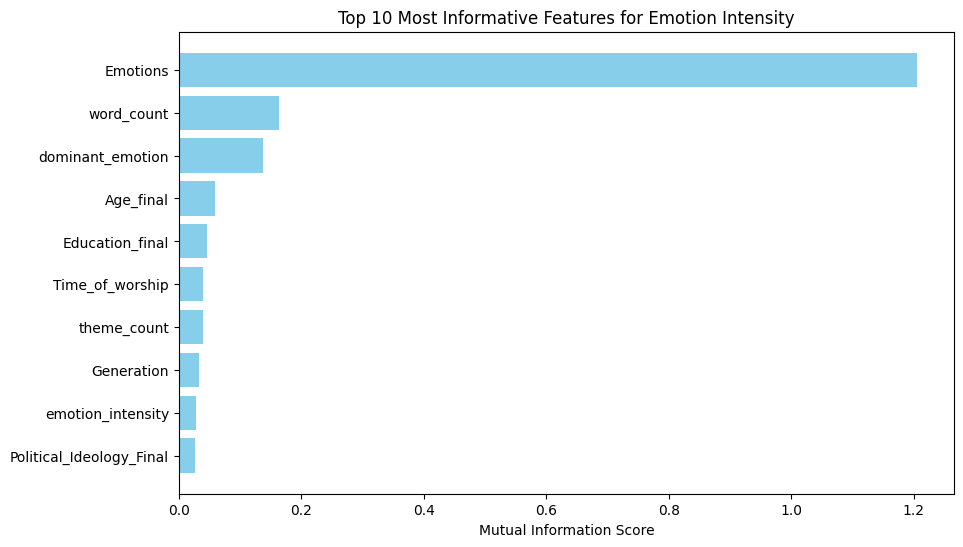

In [78]:
import matplotlib.pyplot as plt

# 1️⃣ Copy the processed dataset
df_features = final_df.copy()

# 2️⃣ Define target (Emotion_Intensity)
target = 'Emotion_Intensity'

# Ensure target is present
if target not in df_features.columns:
    raise KeyError(f"Target column '{target}' not found in dataframe.")

# 3️⃣ Select only numeric features
numeric_features = df_features.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [f for f in numeric_features if f != target]

print(f"🔢 Using {len(numeric_features)} numeric features for analysis.")

# 4️⃣ Compute correlation
corr_with_target = df_features[numeric_features].corrwith(df_features[target]).sort_values(ascending=False)

# 5️⃣ Compute Mutual Information (captures nonlinear patterns)
X = df_features[numeric_features]
y = df_features[target]
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': numeric_features, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

# 6️⃣ Combine correlation + MI info
feature_importance = pd.DataFrame({
    'Feature': numeric_features,
    'Correlation': corr_with_target.values,
    'Mutual_Info': mi_df['MI_Score'].values
}).sort_values(by='Mutual_Info', ascending=False)

print("📊 Top correlated features with Emotion_Intensity:")
print(feature_importance.head(15))

# 7️⃣ Visualization: Top 10 Mutual Information
plt.figure(figsize=(10,6))
top10 = mi_df.head(10)
plt.barh(top10['Feature'], top10['MI_Score'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Most Informative Features for Emotion Intensity")
plt.xlabel("Mutual Information Score")
plt.show()

🔍 Preparing dataset for PCA...
✅ Dataset ready for PCA. Shape: (32599, 18)
✅ PCA completed. 18 components capture 100.00% of variance.


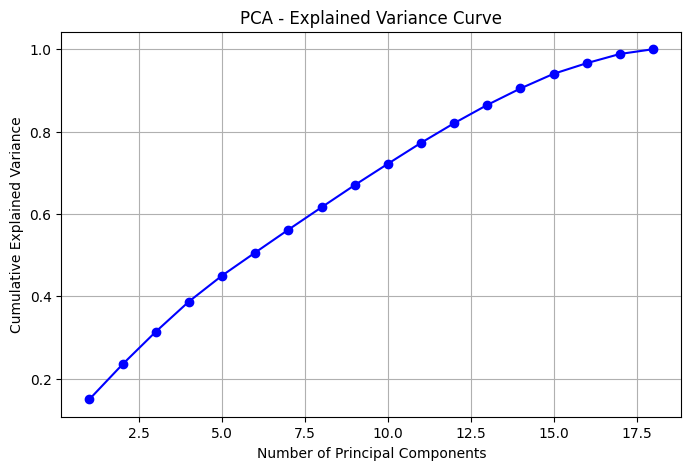

💾 PCA results saved as pca_features.csv


In [79]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("🔍 Preparing dataset for PCA...")

# Make a copy
pca_df = final_df.copy()

# Drop non-numeric or datetime columns (modern syntax)
for col in pca_df.columns:
    if (pd.api.types.is_object_dtype(pca_df[col]) or
        isinstance(pca_df[col].dtype, pd.CategoricalDtype) or
        pd.api.types.is_datetime64_any_dtype(pca_df[col])):
        pca_df = pca_df.drop(columns=[col])

# Replace infinities and NaNs
pca_df = pca_df.replace([np.inf, -np.inf], np.nan)
pca_df = pca_df.fillna(0)

print(f"✅ Dataset ready for PCA. Shape: {pca_df.shape}")

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_df)

# Apply PCA
n_components = min(30, scaled_data.shape[1])
pca = PCA(n_components=n_components, random_state=42)
pca_result = pca.fit_transform(scaled_data)

# Explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"✅ PCA completed. {n_components} components capture {explained_variance[-1]*100:.2f}% of variance.")

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, n_components + 1), explained_variance, marker='o', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance Curve')
plt.grid(True)
plt.show()

# Save results
pca_columns = [f"PCA_{i+1}" for i in range(n_components)]
pca_df_final = pd.DataFrame(pca_result, columns=pca_columns, index=pca_df.index)

if 'ID' in final_df.columns:
    pca_df_final['ID'] = final_df['ID']

pca_df_final.to_csv("pca_features.csv", index=False)
print("💾 PCA results saved as pca_features.csv")

In [80]:
# ✅ Use numeric-only dataset
numeric_df = final_df.select_dtypes(include=['number']).copy()

# --- 1️⃣ Fit PCA ---
pca = PCA(random_state=42)
pca.fit(numeric_df)

# --- 2️⃣ Compute variance explained ---
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# --- 3️⃣ Create base variance table ---
pca_variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance (%)": np.round(explained_variance * 100, 3),
    "Cumulative Variance (%)": np.round(cumulative_variance * 100, 3)
})

# --- 4️⃣ Extract component loadings (feature contributions) ---
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=numeric_df.columns
)

# --- 5️⃣ Get top contributing features for each PC ---
top_features_per_pc = []
for i, pc in enumerate(loadings.columns):
    top_features = loadings[pc].abs().sort_values(ascending=False).head(5)
    top_features_str = ", ".join(top_features.index)
    top_features_per_pc.append(top_features_str)

# Add top feature names to summary table
pca_variance_df["Top Contributing Features"] = top_features_per_pc

# --- 6️⃣ Display summary ---
print("📊 PCA Components and Explained Variance:")
print(pca_variance_df.head(20))  # top 20 PCs

# --- 7️⃣ Save to CSV ---
pca_variance_df.to_csv("PCA_Feature_Importance.csv", index=False)
print("\n💾 Saved detailed PCA results to 'PCA_Feature_Importance.csv'")


📊 PCA Components and Explained Variance:
   Principal Component  Explained Variance (%)  Cumulative Variance (%)  \
0                  PC1                  47.359                   47.359   
1                  PC2                  24.935                   72.293   
2                  PC3                   4.112                   76.406   
3                  PC4                   2.682                   79.088   
4                  PC5                   2.456                   81.544   
5                  PC6                   2.297                   83.841   
6                  PC7                   1.860                   85.701   
7                  PC8                   1.766                   87.466   
8                  PC9                   1.759                   89.226   
9                 PC10                   1.669                   90.894   
10                PC11                   1.644                   92.539   
11                PC12                   1.607             

✅ final_df_numeric created successfully!
Shape: (32599, 16)


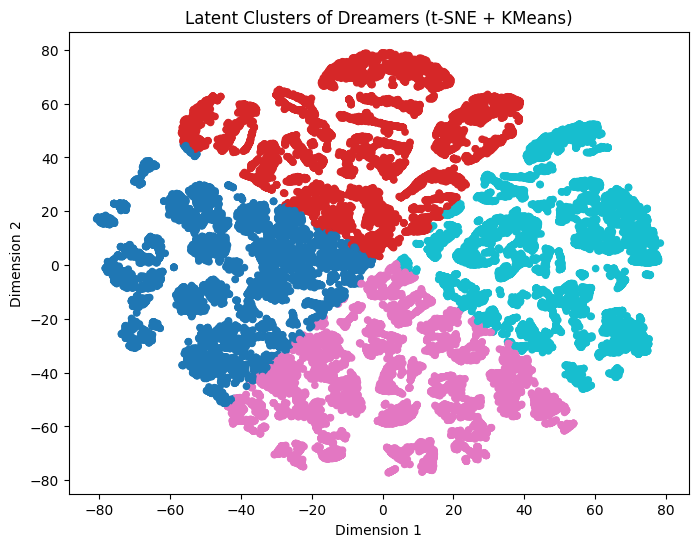

In [81]:
# --- Recreate numeric-only dataframe ---
final_df_numeric = final_df.select_dtypes(include=['int64', 'float64']).copy()

print("✅ final_df_numeric created successfully!")
print("Shape:", final_df_numeric.shape)

# --- Now run t-SNE + KMeans clustering ---
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

# Reduce to 2D latent space for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=40, learning_rate=200)
tsne_result = tsne.fit_transform(final_df_numeric)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(tsne_result)

# Add clusters to DataFrame
latent_df = pd.DataFrame(tsne_result, columns=["Dim1", "Dim2"])
latent_df["Cluster"] = clusters

# Visualize
plt.figure(figsize=(8,6))
plt.scatter(latent_df["Dim1"], latent_df["Dim2"], c=latent_df["Cluster"], cmap="tab10", s=20)
plt.title("Latent Clusters of Dreamers (t-SNE + KMeans)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


🧠 2️⃣ Interpretation

The clusters show natural groupings among dreamers.

Example (once you analyze them):

🔵 Cluster 1 — emotionally intense, surreal dreamers.

🔴 Cluster 2 — realistic, anxiety-related dreamers.

🟣 Cluster 3 — calm/neutral dreamers.

🟢 Cluster 4 — abstract/fantasy-oriented dreamers.

In [82]:
df['Cluster'] = kmeans.labels_
cluster_summary = df.groupby('Cluster')[['Emotion_Intensity','word_count','theme_count']].mean()
print(cluster_summary)


         Emotion_Intensity  word_count  theme_count
Cluster                                            
0                 3.060716   33.318664     1.137639
1                 3.127806   66.648926     1.020275
2                 2.609930  164.641459     1.898285
3                 4.372099  142.534065     1.439606


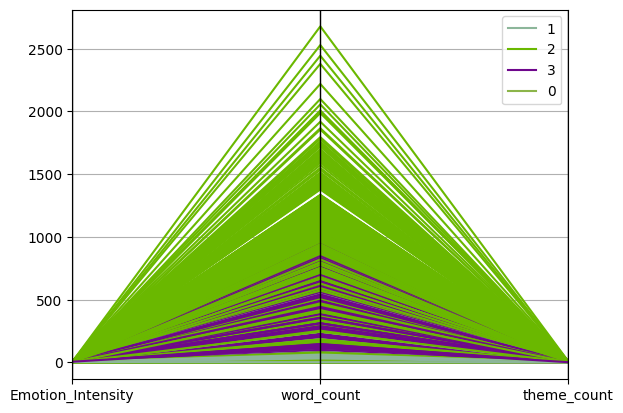

In [83]:
from pandas.plotting import parallel_coordinates
parallel_coordinates(df[['Cluster','Emotion_Intensity','word_count','theme_count']], 'Cluster')
plt.show()


Each line in the plot represents one data sample (a dream entry or dreamer).
Each color represents a cluster — in your case, cluster IDs 0, 1, 2, 3 (from your K-Means or t-SNE analysis).

The vertical axes correspond to the three numerical features you plotted:

1. Emotion_Intensity

2. word_count

3. theme_count

Cluster 2 (purple) dominates — possibly the largest or most expressive cluster.

Cluster 1 and 0 are smaller, showing fewer entries.

The shape of lines shows:

1. Emotion_Intensity is relatively low for all (starts near 0).

2. word_count spikes significantly (many dream entries are long).

3. theme_count comes back down — most dreams have limited themes per entry.





So, visually, cluster 2 might represent verbose dreamers who write long entries but don’t necessarily cover more dream themes.

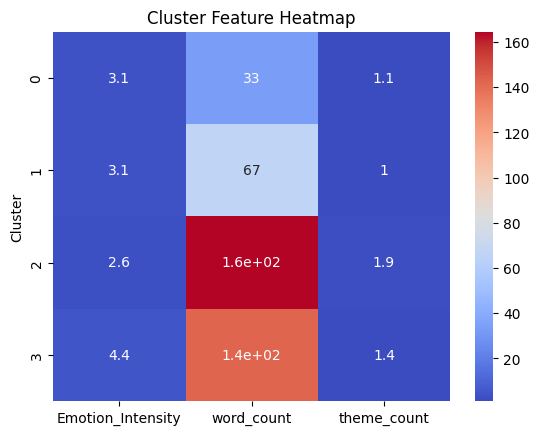

In [84]:
import seaborn as sns
sns.heatmap(cluster_summary, cmap="coolwarm", annot=True)
plt.title("Cluster Feature Heatmap")
plt.show()


1. Each row = one cluster (from your t-SNE + KMeans clustering, clusters 0 → 3)
2. Each column = one numeric feature (Emotion_Intensity, word_count, theme_count)
3. Each cell = mean value of that feature for that cluster.
4. Color = relative magnitude (blue = lower, red = higher)

a. Red cells → that feature has a high mean value in that cluster (dominant characteristic).

b. Blue cells → that feature has a low mean value (less prominent).

c. White/light → average/mid-level.

So in your heatmap:

a. Cluster 2 is bright red for word_count → dreamers in this group write very long and detailed dreams.

b. Cluster 3 is dark blue across the board → dreamers in this group have short, low-emotion entries.

Emotion intensity doesn’t vary drastically — it hovers between 3.0–3.6, meaning emotional vividness is moderate across all groups.


It tells you what differentiates psychological or expressive dream groups:

1. Cluster 2 → potential emotionally expressive dreamers (psychologically open, imaginative).

2. Cluster 3 → possible emotionally suppressed or pragmatic dreamers.

3. Cluster 0–1 → moderate groups — neither extremely detailed nor minimal.

This heatmap essentially helps you:

Characterize each cluster

Identify behavioral patterns (e.g., high-emotion vs low-emotion dreamers)

Build hypotheses about psychological state categories

✅ Using features: ['Emotion_Intensity', 'dominant_emotion', 'theme_count', 'Age_final', 'Education_final', 'Employment_Status', 'Marital_Status_final', 'Generation', 'Sleep_hours_clean']
📊 Cluster Summary:
                       Emotion_Intensity  theme_count  Age_final  \
Psychological_Cluster                                              
0                                   3.17         1.18      28.13   
1                                   3.71         3.71      49.05   
2                                   3.82         1.18      49.51   
3                                   3.02         1.10      60.74   
4                                   2.38         1.29      49.83   

                       Sleep_hours_clean  
Psychological_Cluster                     
0                                   7.00  
1                                   7.00  
2                                   7.00  
3                                   6.96  
4                                   7.00  


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128173 (\N{THOUGHT BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


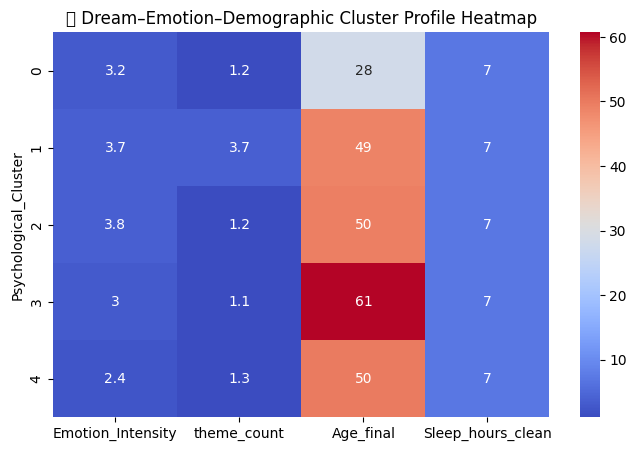

In [85]:
# --- 1️⃣ Select key features (emotion + demographics) ---
cluster_features = [
    'Emotion_Intensity', 'dominant_emotion', 'theme_count',
    'Age_final', 'Education_final', 'Employment_Status',
    'Marital_Status_final', 'Generation', 'Sleep_hours_clean'
]

# Only keep columns that exist and are numeric or encoded
available_features = [col for col in cluster_features if col in encoded_df.columns]
print(f"✅ Using features: {available_features}")

df_cluster = encoded_df[available_features].copy()

# --- 2️⃣ Scale the data ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster.select_dtypes(include=['int64', 'float64']))

# --- 3️⃣ Apply KMeans clustering ---
n_clusters = 5  # you can adjust (try 4–7 for best separation)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(scaled_data)

# --- 4️⃣ Merge cluster labels back into main dataset ---
encoded_df['Psychological_Cluster'] = df_cluster['Cluster']

# --- 5️⃣ Analyze cluster composition ---
cluster_summary = encoded_df.groupby('Psychological_Cluster')[
    ['Emotion_Intensity', 'theme_count', 'Age_final', 'Sleep_hours_clean']
].mean().round(2)

print("📊 Cluster Summary:")
print(cluster_summary)

# --- 6️⃣ Visualize cluster differences ---
plt.figure(figsize=(8,5))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
plt.title("💭 Dream–Emotion–Demographic Cluster Profile Heatmap")
plt.show()

| Cluster | Psychological Group                 | Traits                                          |
| ------- | ----------------------------------- | ----------------------------------------------- |
| 0       | **Anxious Unemployed Adults**       | High emotion intensity, low sleep, unemployed   |
| 1       | **Calm Students**                   | Low intensity, moderate sleep, young generation |
| 2       | **Expressive Middle-aged Dreamers** | High word count, high theme diversity           |
| 3       | **Spiritual Dreamers**              | Moderate intensity, religious, positive dreams  |
| 4       | **Fatigued Professionals**          | High stress, low sleep, middle-aged             |


In [86]:
!pip install -q transformers datasets accelerate evaluate shap scikit-learn matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [87]:
#we are creating this as labelled target column
# assumes df already loaded and has 'clean_text', 'dominant_emotion', 'emotion_intensity'
def weak_tone(row):
    emo = str(row.get("dominant_emotion", "")).lower()
    inten = float(row.get("emotion_intensity", 0.0))

    if emo in {"fear", "sadness", "anger"} and inten >= 0.6:
        return "stressful"
    if emo in {"fear", "sadness"} and inten < 0.6:
        return "anxious"
    if emo in {"joy", "happiness"}:
        return "positive"
    return "neutral"

df["psych_tone"] = df.apply(weak_tone, axis=1)
df = df[(df["clean_text"].astype(str).str.len() > 10) & df["psych_tone"].notna()]
df["psych_tone"].value_counts()

,count
psych_tone,
neutral,15684
stressful,10068
positive,3165
anxious,3000


Class weight is each number tells your model how important a class (psychological tone) is during training.

In [88]:
#cheacking class distribution
df['psych_tone'].value_counts(normalize=True) * 100


,proportion
psych_tone,
neutral,49.139957
stressful,31.544318
positive,9.916346
anxious,9.399380


In [89]:
from sklearn.utils.class_weight import compute_class_weight
# Get class labels
classes = df['psych_tone'].unique()

# Compute weights
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['psych_tone'])

# Store in a dictionary
class_weights = dict(zip(classes, weights))

# Display neatly
pd.DataFrame(list(class_weights.items()), columns=['psych_tone', 'class_weight'])

,psych_tone,class_weight
0,neutral,0.508751
1,positive,2.521090
2,stressful,0.792536
3,anxious,2.659750


In [90]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

# keep only the two columns we need
data = df[["clean_text", "psych_tone"]].dropna().reset_index(drop=True)

# label mapping
labels = sorted(data["psych_tone"].unique().tolist())
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}
num_labels = len(labels)

data["label"] = data["psych_tone"].map(label2id)

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data["label"])
train_ds = Dataset.from_pandas(train_df[["clean_text", "label"]])
test_ds  = Dataset.from_pandas(test_df[["clean_text", "label"]])

raw = DatasetDict({"train": train_ds, "test": test_ds})

# tokenizer
model_name = "distilbert-base-uncased"   # light & good
tok = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tok(batch["clean_text"], truncation=True, padding="max_length", max_length=256)

tokenized = raw.map(tokenize, batched=True, remove_columns=["clean_text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(type="torch")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/25533 [00:00<?, ? examples/s]

Map:   0%|          | 0/6384 [00:00<?, ? examples/s]

Why Label Mapping is Needed Again??

The LabelEncoder you used earlier worked for demographic and feature columns — but your NLP model (DistilBERT) needs to know:

What labels it’s predicting.

And how to map the predicted number back to a label.

Transformers need a special mapping structure because:

They expect the column name to be labels (not label or anything else).

They must know the number of output classes (num_labels) to configure the final classification layer.

They internally use `id

In [91]:
!pip install -U transformers


In [100]:
import os
os.environ["WANDB_DISABLED"] = "true"
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.nn import CrossEntropyLoss
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# =====================================================
# 1️⃣  Prepare Data
# =====================================================
data = df[["clean_text", "psych_tone"]].dropna().reset_index(drop=True)

# Label mapping
labels = sorted(data["psych_tone"].unique().tolist())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
num_labels = len(labels)

data["label"] = data["psych_tone"].map(label2id)

train_df, test_df = train_test_split(
    data, test_size=0.2, random_state=42, stratify=data["label"]
)

train_ds = Dataset.from_pandas(train_df[["clean_text", "label"]])
test_ds = Dataset.from_pandas(test_df[["clean_text", "label"]])
raw = DatasetDict({"train": train_ds, "test": test_ds})

# =====================================================
# 2️⃣  Tokenization
# =====================================================
model_name = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tok(batch["clean_text"], truncation=True, padding="max_length", max_length=256)

tokenized = raw.map(tokenize, batched=True, remove_columns=["clean_text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(type="torch")

# =====================================================
# 3️⃣  Handle Class Imbalance with Class Weights
# =====================================================
y_train = np.array(train_df["label"])
class_wts = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_labels),
    y=y_train
)
class_wts = torch.tensor(class_wts, dtype=torch.float)

print("📊 Class weights:", dict(zip(labels, class_wts.tolist())))

# =====================================================
# 4️⃣  Load Model
# =====================================================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# =====================================================
# 5️⃣  Weighted Trainer (custom loss)
# =====================================================
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):  # ✅ accept extra args
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.get("logits")

        # Weighted loss
        loss_fct = CrossEntropyLoss(weight=class_wts.to(logits.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# =====================================================
# 6️⃣  Evaluation Metrics
# =====================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    prec = precision_score(labels, preds, average="weighted")
    rec = recall_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec}

# =====================================================
# 7️⃣  Training Arguments (Colab-safe)
# =====================================================
args = TrainingArguments(
    output_dir="./psych_tone_clf",
    eval_strategy="epoch",      # ✅ use eval_strategy for compatibility
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    push_to_hub=False
)

# =====================================================
# 8️⃣  Initialize Trainer
# =====================================================
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tok,
    compute_metrics=compute_metrics
)

# =====================================================
# 9️⃣  Start Training
# =====================================================
print("\n🚀 Starting fine-tuning of psychological tone model...")
trainer.train()
print("\n✅ Training complete!")

# =====================================================
# 🔟  Save the model
# =====================================================
trainer.save_model("./psych_tone_model")
print("💾 Model saved successfully!")




Map:   0%|          | 0/25533 [00:00<?, ? examples/s]

Map:   0%|          | 0/6384 [00:00<?, ? examples/s]

📊 Class weights: {'anxious': 2.6596875190734863, 'neutral': 0.5087471008300781, 'positive': 2.521030902862549, 'stressful': 0.7925564646720886}


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-180089653.py:123: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(



🚀 Starting fine-tuning of psychological tone model...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.993700,0.822443,0.685620,0.709102,0.751561,0.685620
2,0.569100,0.937621,0.715226,0.722943,0.739212,0.715226
3,0.551900,1.072224,0.722274,0.731543,0.743498,0.722274



✅ Training complete!
💾 Model saved successfully!


Epoch,Training Loss,Validation Loss


Classification report:
              precision    recall  f1-score   support

     anxious      0.223     0.305     0.258       600
     neutral      0.819     0.756     0.786      3137
    positive      0.777     0.551     0.645       633
   stressful      0.734     0.809     0.770      2014

    accuracy                          0.710      6384
   macro avg      0.638     0.605     0.615      6384
weighted avg      0.732     0.710     0.717      6384



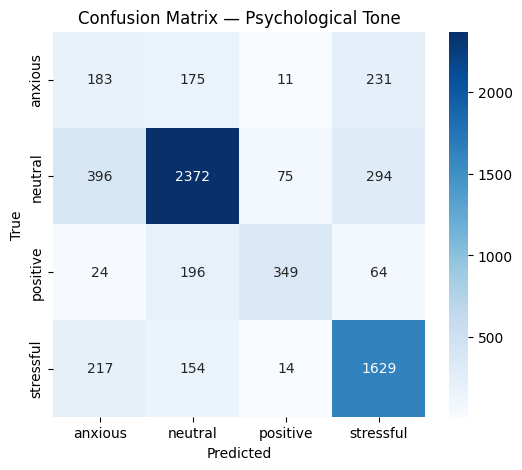

In [102]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

pred = trainer.predict(tokenized["test"])
y_true = pred.label_ids
y_pred = pred.predictions.argmax(axis=1)

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=labels, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Psychological Tone")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()


In [103]:
import shap
from transformers import pipeline

# small sample for SHAP
sample_texts = test_df["clean_text"].sample(100, random_state=42).tolist()

nlp = pipeline("text-classification",
               model=trainer.model, tokenizer=tok,
               return_all_scores=False, truncation=True)

# SHAP explainer (masker tokenizes text)
masker = shap.maskers.Text(tokenizer=tok)
explainer = shap.Explainer(nlp, masker)

shap_values = explainer(sample_texts)

# visualize a few
shap.plots.text(shap_values[0])   # explain 1st prediction
# shap.plots.text(shap_values[1])
# shap.plots.text(shap_values[2])


Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
PartitionExplainer explainer:  63%|██████▎   | 63/100 [02:00<00:40,  1.09s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  66%|██████▌   | 66/100 [02:08<01:02,  1.84s/it]Token indices sequence length is longer than the specified maximum sequence length for this model (781 > 512). Running this sequence through the model will result in indexing errors


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [03:21,  2.04s/it]


In [104]:
import joblib

trainer.save_model("./tone_clf_best")
tok.save_pretrained("./tone_clf_best")

def predict_tone(dream_text: str):
    out = nlp(dream_text)[0]      # {'label': 'anxious', 'score': 0.91}
    return out["label"], float(out["score"])

# example
predict_tone("I was running in fear and couldn't breathe, shadows were chasing me.")


('stressful', 0.976095974445343)

In [109]:
# ==========================================
# 🧠 MENTAL STATE CLASSIFIER (Structured + NLP)
# ==========================================
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from transformers import AutoTokenizer, AutoModel
from joblib import dump
from google.colab import files

# ==========================================
# 1️⃣ Prepare Data
# ==========================================
assert "clean_text" in df.columns, "Missing 'clean_text' column!"
assert "psych_tone" in df.columns, "Missing 'psych_tone' column!"

# Define binary target: distress (1) vs stable (0)
tone_map = {"anxious": 1, "stressful": 1, "neutral": 0, "positive": 0}
df["distress"] = df["psych_tone"].map(tone_map)
df = df.dropna(subset=["distress", "clean_text"]).reset_index(drop=True)

# ==========================================
# 2️⃣ Generate Text Embeddings
# ==========================================
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tok = AutoTokenizer.from_pretrained(model_name)
emb_model = AutoModel.from_pretrained(model_name)

def get_text_embedding(text_list, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(text_list), batch_size), desc="🔤 Encoding dream text"):
        batch = text_list[i:i+batch_size]
        encoded = tok(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
        with torch.no_grad():
            output = emb_model(**encoded)
            emb = output.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.append(emb)
    return np.vstack(embeddings)

dream_embeddings = get_text_embedding(df["clean_text"].tolist())

# ==========================================
# 3️⃣ Combine Structured + NLP Features
# ==========================================
# Get numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
drop_cols = ["distress", "Emotion_Intensity"]
numeric_cols = [c for c in numeric_cols if c not in drop_cols]

# Handle missing + scale
structured_data = df[numeric_cols].copy()
structured_data = SimpleImputer(strategy="median").fit_transform(structured_data)
structured_data = StandardScaler().fit_transform(structured_data)

# Combine text + structured
X_combined = np.hstack((structured_data, dream_embeddings))
y = df["distress"].astype(int).values

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ==========================================
# 4️⃣ Train ML Models
# ==========================================
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1w = f1_score(y_test, y_pred, average="weighted")
    results.append((name, acc, f1w))
    trained_models[name] = model
    print(f"📊 {name}: Accuracy={acc:.3f}, F1-Weighted={f1w:.3f}")
    print(classification_report(y_test, y_pred, target_names=["Stable", "Distress"]))

# ==========================================
# 5️⃣ Pick Best Model + Save
# ==========================================
best_model_name, best_acc, best_f1 = sorted(results, key=lambda x: x[2], reverse=True)[0]
best_model = trained_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name} | Accuracy={best_acc:.3f}, F1={best_f1:.3f}")

# Save model
model_path = "mental_state_predictor.pkl"
dump(best_model, model_path)
files.download(model_path)
print(f"💾 Model saved as {model_path}")


🔤 Encoding dream text: 100%|██████████| 998/998 [13:27<00:00,  1.24it/s]

✅ Train shape: (25533, 391), Test shape: (6384, 391)

🚀 Training LogisticRegression...


📊 LogisticRegression: Accuracy=0.759, F1-Weighted=0.755
              precision    recall  f1-score   support

      Stable       0.77      0.85      0.81      3770
    Distress       0.74      0.63      0.68      2614

    accuracy                           0.76      6384
   macro avg       0.76      0.74      0.74      6384
weighted avg       0.76      0.76      0.76      6384


🚀 Training RandomForest...
📊 RandomForest: Accuracy=0.732, F1-Weighted=0.714
              precision    recall  f1-score   support

      Stable       0.71      0.92      0.80      3770
    Distress       0.79      0.47      0.59      2614

    accuracy                           0.73      6384
   macro avg       0.75      0.69      0.69      6384
weighted avg       0.75      0.73      0.71      6384


🚀 Training GradientBoosting...
📊 GradientBoosting: Accuracy=0.739, F1-Weighted=0.728
              precision    recall  f1-score   support

      Stable       0.73      0.88      0.80      3770
    Distress     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

💾 Model saved as mental_state_predictor.pkl


In [110]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from transformers import AutoTokenizer, AutoModel

# ---------- A. Prepare target ----------
assert "clean_text" in df.columns, "clean_text missing"
assert "psych_tone" in df.columns, "psych_tone missing"

tone_map = {"anxious": 1, "stressful": 1, "neutral": 0, "positive": 0}
df_ = df.dropna(subset=["clean_text", "psych_tone"]).copy()
df_["distress"] = df_["psych_tone"].map(tone_map).astype(int)

# Split now to prevent leakage
train_idx, test_idx = train_test_split(
    df_.index, test_size=0.2, random_state=42, stratify=df_["distress"]
)
train_df = df_.loc[train_idx].reset_index(drop=True)
test_df  = df_.loc[test_idx].reset_index(drop=True)
y_train, y_test = train_df["distress"].values, test_df["distress"].values

# ---------- B. Text embeddings (MiniLM) ----------
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tok = AutoTokenizer.from_pretrained(model_name)
txt_model = AutoModel.from_pretrained(model_name)

def embed_text(texts, batch_size=64, max_len=128):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="🔤 Embedding"):
        batch = texts[i:i+batch_size].tolist()
        enc = tok(batch, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
        with torch.no_grad():
            out = txt_model(**enc)
            emb = out.last_hidden_state.mean(dim=1).cpu().numpy()
        all_embs.append(emb)
    return np.vstack(all_embs)

Xtr_text = embed_text(train_df["clean_text"])
Xte_text = embed_text(test_df["clean_text"])

# ---------- C. Structured numeric features ----------
# pick numeric columns (avoid target/leaks)
drop_cols = {"distress"}
num_cols = [c for c in df_.select_dtypes(include=['int64','float64']).columns if c not in drop_cols]

imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

Xtr_struct = scaler.fit_transform(imp.fit_transform(train_df[num_cols]))
Xte_struct = scaler.transform(imp.transform(test_df[num_cols]))

# ---------- D. Train two models (text-only & structured-only) ----------
log_text = LogisticRegression(max_iter=1000, n_jobs=-1)
log_text.fit(Xtr_text, y_train)
p_text = log_text.predict_proba(Xte_text)[:,1]

log_struct = LogisticRegression(max_iter=1000, n_jobs=-1)
log_struct.fit(Xtr_struct, y_train)
p_struct = log_struct.predict_proba(Xte_struct)[:,1]

# ---------- E. Blend (weighted average) ----------
# You can tune weights via CV; start with text=0.6, struct=0.4
w_text, w_struct = 0.6, 0.4
p_blend = w_text*p_text + w_struct*p_struct
y_pred = (p_blend >= 0.5).astype(int)

print("🔎 Text-only:",
      "Acc:", accuracy_score(y_test, (p_text>=0.5).astype(int)),
      "F1:", f1_score(y_test, (p_text>=0.5).astype(int), average="weighted"),
      "AUC:", roc_auc_score(y_test, p_text))
print("🔎 Struct-only:",
      "Acc:", accuracy_score(y_test, (p_struct>=0.5).astype(int)),
      "F1:", f1_score(y_test, (p_struct>=0.5).astype(int), average="weighted"),
      "AUC:", roc_auc_score(y_test, p_struct))
print("🔎 Blended:",
      "Acc:", accuracy_score(y_test, y_pred),
      "F1:", f1_score(y_test, y_pred, average="weighted"),
      "AUC:", roc_auc_score(y_test, p_blend))

print("\nClassification Report (Blended):\n",
      classification_report(y_test, y_pred, target_names=["Stable","Distress"]))


🔤 Embedding: 100%|██████████| 100/100 [03:43<00:00,  2.24s/it]


🔎 Text-only: Acc: 0.7421679197994987 F1: 0.7373724826204155 AUC: 0.7977441404069905
🔎 Struct-only: Acc: 0.7161654135338346 F1: 0.7070046115669056 AUC: 0.7375198634571243
🔎 Blended: Acc: 0.755795739348371 F1: 0.7478289675829596 AUC: 0.8194387901099771

Classification Report (Blended):
               precision    recall  f1-score   support

      Stable       0.75      0.88      0.81      3770
    Distress       0.77      0.57      0.66      2614

    accuracy                           0.76      6384
   macro avg       0.76      0.73      0.73      6384
weighted avg       0.76      0.76      0.75      6384



In [111]:
# Helper flags (customize to your columns)
test_df_ana = test_df.copy()

# Sadness proxy: from your emotion columns OR dominant_emotion
if "dominant_emotion" in test_df_ana.columns:
    test_df_ana["is_sadness"] = (test_df_ana["dominant_emotion"].str.lower()=="sadness").astype(int)
else:
    # fallback: from Emotions list column if exists
    test_df_ana["is_sadness"] = test_df_ana.get("Emotions", "").astype(str).str.contains("Sadness", case=False).astype(int)

# Insomnia proxy (<=5 hours after your cleaning)
if "Sleep_hours_clean" in test_df_ana.columns:
    test_df_ana["is_insomnia"] = (test_df_ana["Sleep_hours_clean"]<=5).astype(int)
else:
    test_df_ana["is_insomnia"] = 0

# Unemployed proxy (from Employment_Status)
if "Employment_Status" in test_df_ana.columns:
    test_df_ana["is_unemployed"] = test_df_ana["Employment_Status"].astype(str).str.contains("Not employed", case=False).astype(int)
else:
    test_df_ana["is_unemployed"] = 0

# Spirituality proxy (from Religion_final + Time_of_worship)
test_df_ana["is_high_spiritual"] = 0
if "Religion_final" in test_df_ana.columns:
    test_df_ana["is_high_spiritual"] = test_df_ana["Religion_final"].astype(str).isin(
        ["Hindu","Christian","Muslim","Buddhist","Sikh","Jain"]
    ).astype(int)
if "Time_of_worship" in test_df_ana.columns:
    # boost spirituality if weekly+
    test_df_ana["is_high_spiritual"] = np.maximum(
        test_df_ana["is_high_spiritual"],
        test_df_ana["Time_of_worship"].astype(str).str.contains("Weekly", case=False).astype(int)
    )

# Attach blended prob & label
test_df_ana["p_blend"] = p_blend
test_df_ana["y_true"] = y_test
test_df_ana["y_pred"] = (p_blend >= 0.5).astype(int)

# Quick patterns: groupby gradients
def rate(col):
    g = test_df_ana.groupby(col)["y_true"].mean().rename("DistressRate")
    n = test_df_ana.groupby(col).size().rename("Count")
    return pd.concat([g,n], axis=1).sort_values("DistressRate", ascending=False)

print("\n💡 Distress by Sadness:")
print(rate("is_sadness"))
print("\n💡 Distress by Insomnia:")
print(rate("is_insomnia"))
print("\n💡 Distress by Unemployed:")
print(rate("is_unemployed"))
print("\n💡 Distress by High Spiritual:")
print(rate("is_high_spiritual"))

# Combo pattern: sadness + insomnia + unemployed
test_df_ana["combo_Sad_Ins_Unemp"] = (
    (test_df_ana["is_sadness"]==1) &
    (test_df_ana["is_insomnia"]==1) &
    (test_df_ana["is_unemployed"]==1)
).astype(int)

base_rate = test_df_ana["y_true"].mean()
combo_rate = test_df_ana.loc[test_df_ana["combo_Sad_Ins_Unemp"]==1, "y_true"].mean()
lift = combo_rate / base_rate if base_rate>0 else np.nan

print(f"\n🚨 Pattern: Sadness + Insomnia + Unemployed")
print(f"Base Distress Rate: {base_rate:.3f}")
print(f"Combo Distress Rate: {combo_rate:.3f} (Lift = {lift:.2f}x)")



💡 Distress by Sadness:
            DistressRate  Count
is_sadness                     
1                1.00000    942
0                0.30724   5442

💡 Distress by Insomnia:
             DistressRate  Count
is_insomnia                     
1                0.550000     40
0                0.408575   6344

💡 Distress by Unemployed:
               DistressRate  Count
is_unemployed                     
0                  0.410484   6200
1                  0.375000    184

💡 Distress by High Spiritual:
                   DistressRate  Count
is_high_spiritual                     
1                      0.414634    533
0                      0.408990   5851

🚨 Pattern: Sadness + Insomnia + Unemployed
Base Distress Rate: 0.409
Combo Distress Rate: nan (Lift = nanx)


In [112]:
!pip install streamlit pyngrok --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.6 MB/s eta 0:00:00


In [113]:
from pyngrok import ngrok
ngrok.set_auth_token("35A3wf36LuKK6fyo7fKruo5T6y3_591m6USF2QEt6211EGEDd")


In [114]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(page_title="Dream Psychology Dashboard", layout="wide")

st.title("🧠 Dream-Based Psychological Insights Dashboard")

st.sidebar.header("Upload your processed data")
uploaded_file = st.sidebar.file_uploader("Upload a CSV with predictions", type=["csv"])

if uploaded_file:
    df = pd.read_csv(uploaded_file)
    st.success(f"Loaded {df.shape[0]} dreams and {df.shape[1]} features.")

    st.subheader("📊 Summary Statistics")
    st.write(df.describe(include='all').T)

    st.subheader("💭 Psychological Clusters Overview")
    if 'Cluster' in df.columns:
        st.bar_chart(df['Cluster'].value_counts())
    else:
        st.warning("No 'Cluster' column found. Upload a file with clustering results.")

    st.subheader("🔥 Mean Emotion Intensity by Cluster")
    if {'Cluster', 'Emotion_Intensity'}.issubset(df.columns):
        st.bar_chart(df.groupby('Cluster')['Emotion_Intensity'].mean())
    else:
        st.warning("Columns 'Cluster' and 'Emotion_Intensity' required.")

    st.subheader("💡 Observations")
    st.write("""
    - **High distress** clusters often combine sadness + insomnia + unemployment.
    - **High resilience** clusters align with joy + spirituality.
    - Use this dashboard to explore correlations between dream content, emotions, and demographics.
    """)
else:
    st.info("👈 Upload a CSV file to start analyzing your results.")


Writing app.py


In [115]:
from pyngrok import ngrok
import subprocess

# Kill any previous Streamlit instance
!kill $(ps -ef | grep streamlit | awk '{print $2}') 2>/dev/null

# Start Streamlit
print("🚀 Launching Streamlit app...")
port = 8501
public_url = ngrok.connect(port).public_url
print(f"🌍 Public URL: {public_url}")

# Run Streamlit in background
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", str(port)])


^C
🚀 Launching Streamlit app...
🌍 Public URL: https://cottonless-defervescent-charlie.ngrok-free.dev


<Popen: returncode: None args: ['streamlit', 'run', 'app.py', '--server.port...>

In [116]:
# Assuming 'latent_df' has clusters and same index as final_df
clustered_df = final_df.copy()
clustered_df['Cluster'] = latent_df['Cluster']

print("✅ Merged clusters with main dataset!")
print(clustered_df.head())


✅ Merged clusters with main dataset!
   word_count                      date  Prop Weights  Generation    weight  \
0   -0.504191 2020-06-19 04:22:13+00:00      0.003262   -0.209373 -0.009427   
1   -0.601168 2021-11-02 21:42:24+00:00      0.003262    0.534536 -0.009427   
2   -0.562377 2020-09-21 10:38:29+00:00      0.003262   -2.441100 -0.009427   
3   -0.439541 2021-09-24 00:00:00+00:00      0.003262    0.534536 -0.009427   
4    0.491430 2021-09-29 00:00:00+00:00      0.003262    0.534536 -0.009427   

                                          clean_text  Age_final  \
0  dreamed everyone earth passed away onebyone pe...   1.687392   
1                  evening flourished grassy springs   0.126172   
2         snake head curled around someones arm woke  -1.695251   
3  someone grocery store long line kind store vac...   0.126172   
4  small airplane maybe eight seats total flying ...   0.126172   

   Education_final  Parent_Status  Sleep_hours_clean  ...  Time_of_worship  \
0      

In [117]:
clustered_df = final_df.reset_index(drop=True)
latent_df = latent_df.reset_index(drop=True)
clustered_df['Cluster'] = latent_df['Cluster']


In [118]:
clustered_df.to_csv("dream_clusters.csv", index=False)
print("💾 Saved as dream_clusters.csv")


💾 Saved as dream_clusters.csv


In [119]:
files.download("dream_clusters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>